In [1]:
%pip install numpy pandas matplotlib seaborn scipy
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
datos = pd.read_csv('C:\\Users\\angel\\Desktop\\PIM4Python\\data_latinoamerica.csv', sep=',')


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [49]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 3.2 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.0 MB 4.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.0 MB 3.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 3.1 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.0 MB 2.9 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/8.0 MB 2.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.0 MB 3.0 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.0 MB 3.0 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 3.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 3.2 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 3.2 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
datos.isnull().sum()

location_key                                    0
date                                            0
country_code                                    0
country_name                                    0
new_confirmed                             5839054
new_deceased                              5893738
cumulative_confirmed                      5838685
cumulative_deceased                       5893376
cumulative_vaccine_doses_administered    11948128
population                                 532167
population_male                           1123794
population_female                         1123794
population_rural                         12196237
population_urban                         12196237
population_density                       12196237
human_development_index                   6705106
population_age_00_09                      1466680
population_age_10_19                      1466680
population_age_20_29                      1466680
population_age_30_39                      1466680


In [3]:
datos.shape      #Registros y columnas completos

(12216057, 50)

In [4]:
datos=datos.dropna(subset=['latitude','longitude'])   #Para análisis geográficos son irrelevantes datos que no cuentan con coordenadas geográficas.

In [5]:
datos['latitude' or 'longitude'].isnull().sum()

np.int64(0)

In [6]:
conteo = datos.groupby('country_name').size()
print(conteo)

country_name
Argentina              517302
Bolivia                  9910
Brazil                5561492
Chile                  358742
Colombia              1142623
Costa Rica               7928
Cuba                    17838
Dominican Republic      32703
Ecuador                 24775
El Salvador             14865
Guatemala               22793
Honduras                18829
Mexico                2084073
Nicaragua               17838
Panama                  13874
Paraguay                18829
Peru                  1883891
Puerto Rico               991
Uruguay                 19820
Venezuela               24775
dtype: int64


In [7]:
datos['date']=pd.to_datetime(datos['date'])

In [8]:
paises=['Colombia', 'Argentina', 'Chile','Mexico', 'Peru', 'Brazil']
datos_filtrados = datos.loc[
    datos["country_name"].isin(paises) & (datos["date"] > "2021-01-01")
]

In [9]:
datos_filtrados["country_name"].unique()

array(['Argentina', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'Peru'],
      dtype=object)

In [10]:
datos_filtrados.shape

(7271472, 50)

In [11]:
conteo=datos_filtrados.groupby('country_name')['population_largest_city'].apply(lambda x:x.isnull().sum())
print(conteo)

country_name
Argentina     325104
Brazil       3501264
Chile         225264
Colombia      718848
Mexico       1311648
Peru         1185600
Name: population_largest_city, dtype: int64


In [55]:
datos_filtrados.describe()

,date,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,population_male,population_female,population_rural,...,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered,mes_año
count,7271472,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,...,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7.271472e+06,7271472
mean,2021-11-09 11:59:59.999999232,2.070503e+01,3.929771e-01,1.097881e+04,2.915210e+02,6.543460e+07,1.285859e+05,2.054533e+05,2.155447e+05,2.023121e+07,...,4.754937e+06,9.258243e+04,7.600289e+01,1.728813e+02,8.826745e+01,3.708552e+01,1.553958e+01,5.348643e+00,3.047304e+03,2021-10-25 22:41:32.307692032
min,2021-01-02 00:00:00,-7.390700e+04,-4.109000e+03,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,1.200000e+01,2.900000e+01,2.341903e+06,...,7.094180e+05,1.202700e+04,7.499200e+01,1.076690e+02,5.903500e+01,2.530000e+01,1.240000e+01,-3.111900e+04,0.000000e+00,2021-01-01 00:00:00
25%,2021-06-06 18:00:00,0.000000e+00,0.000000e+00,1.180000e+02,4.000000e+00,6.836824e+06,4.704000e+03,2.430000e+03,2.372000e+03,9.512141e+06,...,1.256339e+06,3.613200e+04,7.567200e+01,1.516160e+02,8.481500e+01,2.990000e+01,1.570000e+01,0.000000e+00,0.000000e+00,2021-06-01 00:00:00
50%,2021-11-09 12:00:00,0.000000e+00,0.000000e+00,5.440000e+02,1.200000e+01,3.469034e+07,1.204300e+04,6.397000e+03,6.371000e+03,2.494867e+07,...,2.690269e+06,1.024180e+05,7.567200e+01,1.843790e+02,9.142100e+01,2.990000e+01,1.580000e+01,0.000000e+00,0.000000e+00,2021-11-01 00:00:00
75%,2022-04-14 06:00:00,1.000000e+00,0.000000e+00,1.893000e+03,4.100000e+01,8.362493e+07,3.263800e+04,2.017000e+04,2.062900e+04,2.780789e+07,...,8.241430e+06,1.349810e+05,7.651600e+01,1.885280e+02,9.142100e+01,3.700000e+01,1.660000e+01,0.000000e+00,3.000000e+02,2022-04-01 00:00:00
max,2022-09-17 00:00:00,2.984080e+05,1.144700e+04,3.456883e+07,6.852030e+05,3.478685e+08,2.125594e+08,1.044358e+08,1.081236e+08,2.780789e+07,...,8.241430e+06,1.349810e+05,8.004200e+01,1.885280e+02,9.581500e+01,6.390000e+01,1.660000e+01,2.829570e+05,3.370623e+07,2022-09-01 00:00:00
std,NaN,6.834508e+02,1.475425e+01,2.505670e+05,6.397760e+03,7.391590e+07,2.420386e+06,1.264987e+06,1.316840e+06,9.664738e+06,...,3.379533e+06,4.908572e+04,9.591356e-01,2.151925e+01,7.579576e+00,1.230565e+01,1.507252e+00,5.580920e+02,2.147359e+05,NaN


In [12]:
columnas_a_imputar= ['population','population_male','population_female','population_rural','rainfall_mm','area_urban_sq_km','population_largest_city','area_rural_sq_km','relative_humidity','population_urban','population_density','smoking_prevalence','diabetes_prevalence','human_development_index','gdp_usd','gdp_per_capita_usd','life_expectancy','infant_mortality_rate','adult_male_mortality_rate','adult_female_mortality_rate','pollution_mortality_rate','comorbidity_mortality_rate','nurses_per_1000','physicians_per_1000','average_temperature_celsius','minimum_temperature_celsius','maximum_temperature_celsius','population_age_00_09','population_age_10_19','population_age_20_29','population_age_30_39','population_age_40_49','population_age_50_59','population_age_60_69','population_age_70_79','population_age_80_and_older','area_sq_km'] 
for col in columnas_a_imputar:
    media_por_pais=datos_filtrados.groupby('country_name')[col].transform('mean')
    datos_filtrados.loc[:,col]=datos_filtrados[col].fillna(media_por_pais)
    print(f"imputacion por media completada para : {col}")

imputacion por media completada para : population
imputacion por media completada para : population_male
imputacion por media completada para : population_female
imputacion por media completada para : population_rural
imputacion por media completada para : rainfall_mm
imputacion por media completada para : area_urban_sq_km
imputacion por media completada para : population_largest_city
imputacion por media completada para : area_rural_sq_km
imputacion por media completada para : relative_humidity
imputacion por media completada para : population_urban
imputacion por media completada para : population_density
imputacion por media completada para : smoking_prevalence
imputacion por media completada para : diabetes_prevalence
imputacion por media completada para : human_development_index
imputacion por media completada para : gdp_usd
imputacion por media completada para : gdp_per_capita_usd
imputacion por media completada para : life_expectancy
imputacion por media completada para : infant

In [13]:
columnas_acumuladas=['cumulative_recovered','cumulative_confirmed','cumulative_deceased','cumulative_vaccine_doses_administered']
for col in columnas_acumuladas:
    datos_filtrados.loc[:,col] = datos_filtrados[col].ffill().fillna(0)

In [14]:
columnas_por_cero=['new_confirmed','new_deceased','new_recovered']
for col in columnas_por_cero:
    datos_filtrados.loc[:,col]=datos_filtrados[col].fillna(0)

In [15]:
datos_filtrados.isnull().sum()

location_key                             0
date                                     0
country_code                             0
country_name                             0
new_confirmed                            0
new_deceased                             0
cumulative_confirmed                     0
cumulative_deceased                      0
cumulative_vaccine_doses_administered    0
population                               0
population_male                          0
population_female                        0
population_rural                         0
population_urban                         0
population_density                       0
human_development_index                  0
population_age_00_09                     0
population_age_10_19                     0
population_age_20_29                     0
population_age_30_39                     0
population_age_40_49                     0
population_age_50_59                     0
population_age_60_69                     0
population_

In [16]:
conteo=datos_filtrados.groupby('country_name')['population_largest_city'].apply(lambda x:x.isnull().sum())

In [17]:
print(conteo)

country_name
Argentina    0
Brazil       0
Chile        0
Colombia     0
Mexico       0
Peru         0
Name: population_largest_city, dtype: int64


In [18]:
print(datos_filtrados['country_name'].value_counts())

country_name
Brazil       3501888
Mexico       1312272
Peru         1186224
Colombia      719472
Argentina     325728
Chile         225888
Name: count, dtype: int64


In [19]:
datos_filtrados.to_csv(r'\Users\angel\Documents\datos_biogenesys_powerbi', index=False, encoding='utf-8-sig')

In [20]:
import os
ruta_actual=os.getcwd() 
print(f"El archivo está en:/n{ruta_actual}")

El archivo está en:/nc:\Users\angel\Documents\.ipynb_checkpoints


Las variables principales para la demanda de vacunas:necesitamos saber el volumen de vacunas y a quien darselas primero (poblacion por edad es la variable crítica para la segmentación
#comorbilidades como diabetes_prevalence y smoking_prevalence, son grupos de alto riesgo que aumentan la demanda. New confirmed y cumulative confirmed, ayudan a identificar zonas de brotes activos
#donde la vacunacion es prioritaria.
#Logistica de distribución: depende de la geografía y la facilidad de llegada a los puntos. Population_Rural, Population_urban: la distribución en zonas rurales sule requerir una distribución más
#compleja y cadenas de frío portátiles. population_density: áreas con alta densidad permiten centros de vacunación masivos, áreas de baja densidad requieren más puntos de distribución pequeños.
#latitude, longitude: para optimización de rutas y cálculo de tiempos de transporte.
#infraestructura sanitaria existente: mide si el sistema sanitario puede soportar la aplicación de vacunas y atención a enfermos. physicians_per_1000, nurses_per_1000: para conocer si hay suficiente 
#gente para administrar las dosis. gdp_per_capita_usd y human_development_index: países o regiones con mayor IDH suelen tener mejor infraestructura de refrigeración y sistemas de registro digital.
#life_expectancy: indicador indirecto de la robuztes del sistema de salud en la región.

In [21]:
from scipy.stats import skew, kurtosis
print(f"{'Feature':<30} | {'Rango Total':<17} | {'IQR':<17} | {'Media':<17} | {'Desviacion':<16} | {'CV':<8} | {'Sesgo':<8} | {'Curtosis':<8} | {'Mediana':<8}")
columnas_numericas=datos_filtrados.select_dtypes(include=['number']).columns
for col in columnas_numericas:
    val_max=datos_filtrados[col].max()
    val_min=datos_filtrados[col].min()
    rango_total=val_max-val_min
    q1=datos_filtrados[col].quantile(0.25)
    q3=datos_filtrados[col].quantile(0.75)
    iqr=q3-q1
    media=datos_filtrados[col].mean()
    desviacion=datos_filtrados[col].std()
    cv=(desviacion/media) if media != 0 else float('nan')
    sesgo=datos_filtrados[col].skew()
    curtosis=datos_filtrados[col].kurt()
    mediana=datos_filtrados[col].median()
   
    
    print(f"{col[:30]:<30} | {rango_total:<17.2f} | {iqr: <17.2f} | {media:<17.2f} | {desviacion:<16.2f} | {cv:<8.2f} | {sesgo:<8.2f} | {curtosis:<8.2} | {mediana:<8.2}")
    

Feature                        | Rango Total       | IQR               | Media             | Desviacion       | CV       | Sesgo    | Curtosis | Mediana 
new_confirmed                  | 372315.00         | 1.00              | 20.71             | 683.45           | 33.01    | 140.96   | 3.2e+04  | 0.0     
new_deceased                   | 15556.00          | 0.00              | 0.39              | 14.75            | 37.54    | 173.35   | 7.6e+04  | 0.0     
cumulative_confirmed           | 34568833.00       | 1775.00           | 10978.81          | 250566.95        | 22.82    | 88.99    | 9.8e+03  | 5.4e+02 
cumulative_deceased            | 685203.00         | 37.00             | 291.52            | 6397.76          | 21.95    | 72.11    | 6.5e+03  | 1.2e+01 
cumulative_vaccine_doses_admin | 347868481.00      | 76788110.00       | 65434602.42       | 73915897.76      | 1.13     | 1.12     | -0.2     | 3.5e+07 
population                     | 212559405.00      | 27934.00          | 128

#•	¿Qué implican estas métricas y cómo pueden ayudar en el análisis de datos?
#•	¿Se muestran todas las estadísticas en todas las columnas durante el análisis?
#•	¿Cuál es la razón de la respuesta anterior y cómo podría afectar la interpretación de los resultados obtenidos
#El sesgo y la curtosis son medidas de forma de la distribución de los datos, nos dicen que tanto se alejan los datos de la normalidad, el caso base o ideal. El sesgo nos indica hacia que valor 
#se concentran la mayoría de los datos, tenemos sesgo o asimetría positiva; donde la mayoría de los datos se concentran en un valor hacia la izquierda y las colas se van hacia la derecha. Caso
#contrario con la asimetría negativa. La curtosis es otra medida de forma y nos indica que tanto se desvían las colas de la idealidad o de la curva normal en los extremos y en el centro. Tenemos
#curtosis positiva, en la cuál tenemos colas pesadas lo cuál indica la presencia de muchos outliers; en la curtosis negativa los datos están en un rango predecible y casi no hay puntos fuera de
#la normalidad. En cuanto a las medidas de tendencia central es el valor mayormente representativo en la totalidad de nuestros datos, la media se usa cuando nuestros datos no se alejan tanto de la
#forma de gaussiana o no son tan asimétricos. Caso contrario con la mediana es la medida de tendencia central representativa de nuestro conjunto de datos cuando la asimetría es muy alta, ya que ante 
#tales magnitudes de asimetría los valores extremos jalan a la media y ya no es una medida fiable que represente nuestro conjunto de datos, ya que es fuertemente influenciada por estos valores.
#El IQR nos representa donde se concentran el 50% de nuestros datos. Por otro lado el CV (coeficiente de variación) es una medida normalizada para cuantificar la dispersión, se toma como el cociente
#de la desviación estándar/media.
#Crea una función que permita obtener la mediana, varianza y el rango. Te dejamos algunas preguntas para analizar esas medidas:
#•	¿Qué representa la mediana?
#El el valor alrededor del cual se concentran hacia un lado el 50% de nuestros datos y hacia el otro el 50% restante, es una medida robusta y representativa ante al tos sesgos den la distribución.
#•	¿Cómo varía la dispersión de los datos en el conjunto de datos analizado, en términos de la varianza y el rango?
#Dependiendo de la variable se muestran altas dispersiones, con unos rangos altísimos. Algunas son moderadas.
#•	¿Qué nos puede indicar esto sobre la consistencia o la variabilidad de los datos en relación con la mediana?
#nos da una idea de la forma de nuestra distribución de datos, el tamaño de las colas si tenemos muchos outliers, comparando con el CV, que por regla general se considera CV<15%   baja variabilidad
#CV>30% una alta variabilidad, lo que podría indicar la presencia de grupos al tener datos tan dispersos de la mediana. Un CV intermedio se considera variabilidad intermedia.

#AVANCE 2

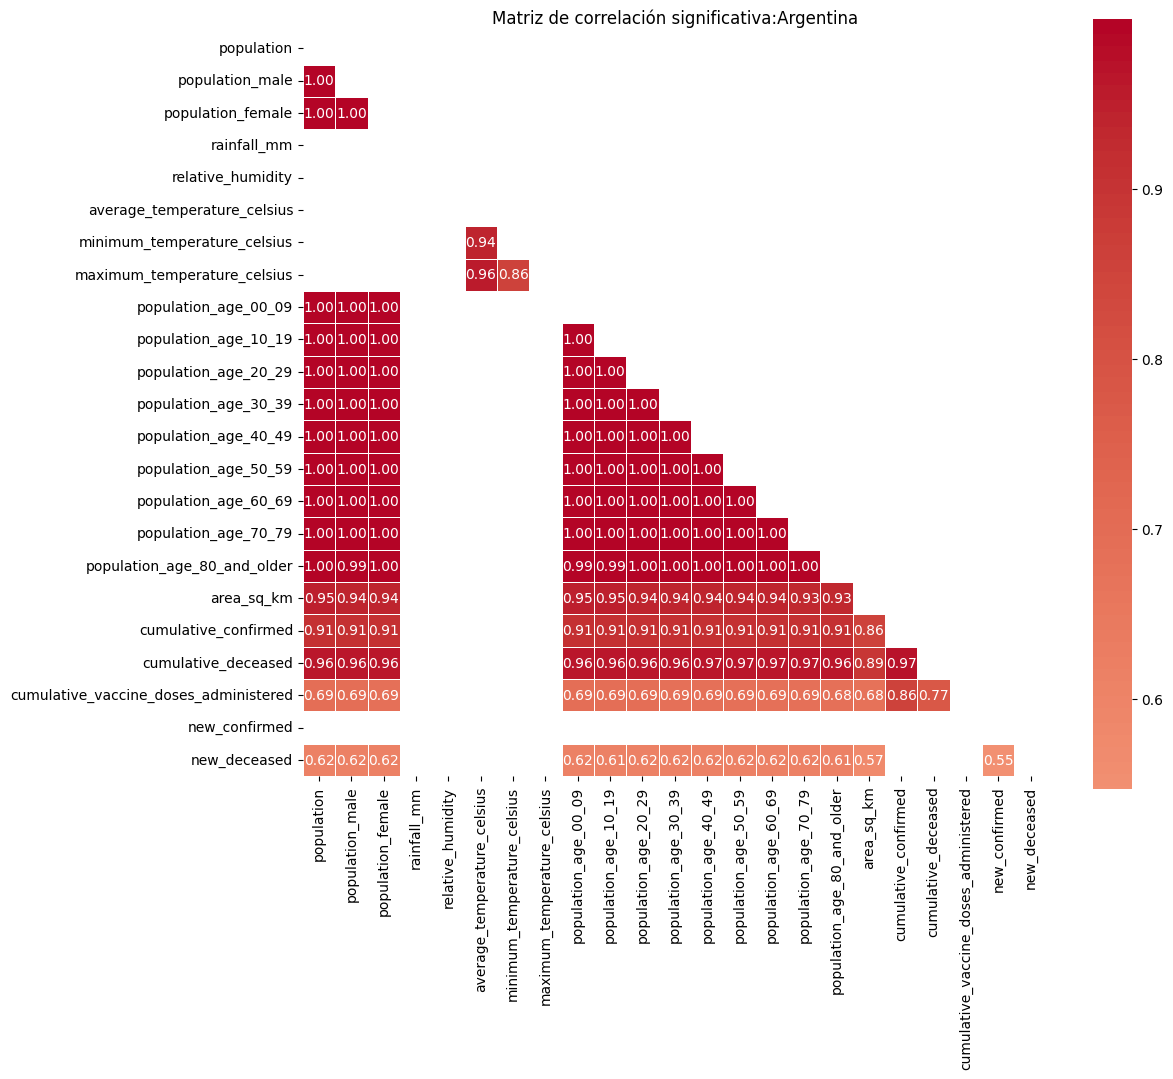

Mapa de calor generado para Argentina con exito.


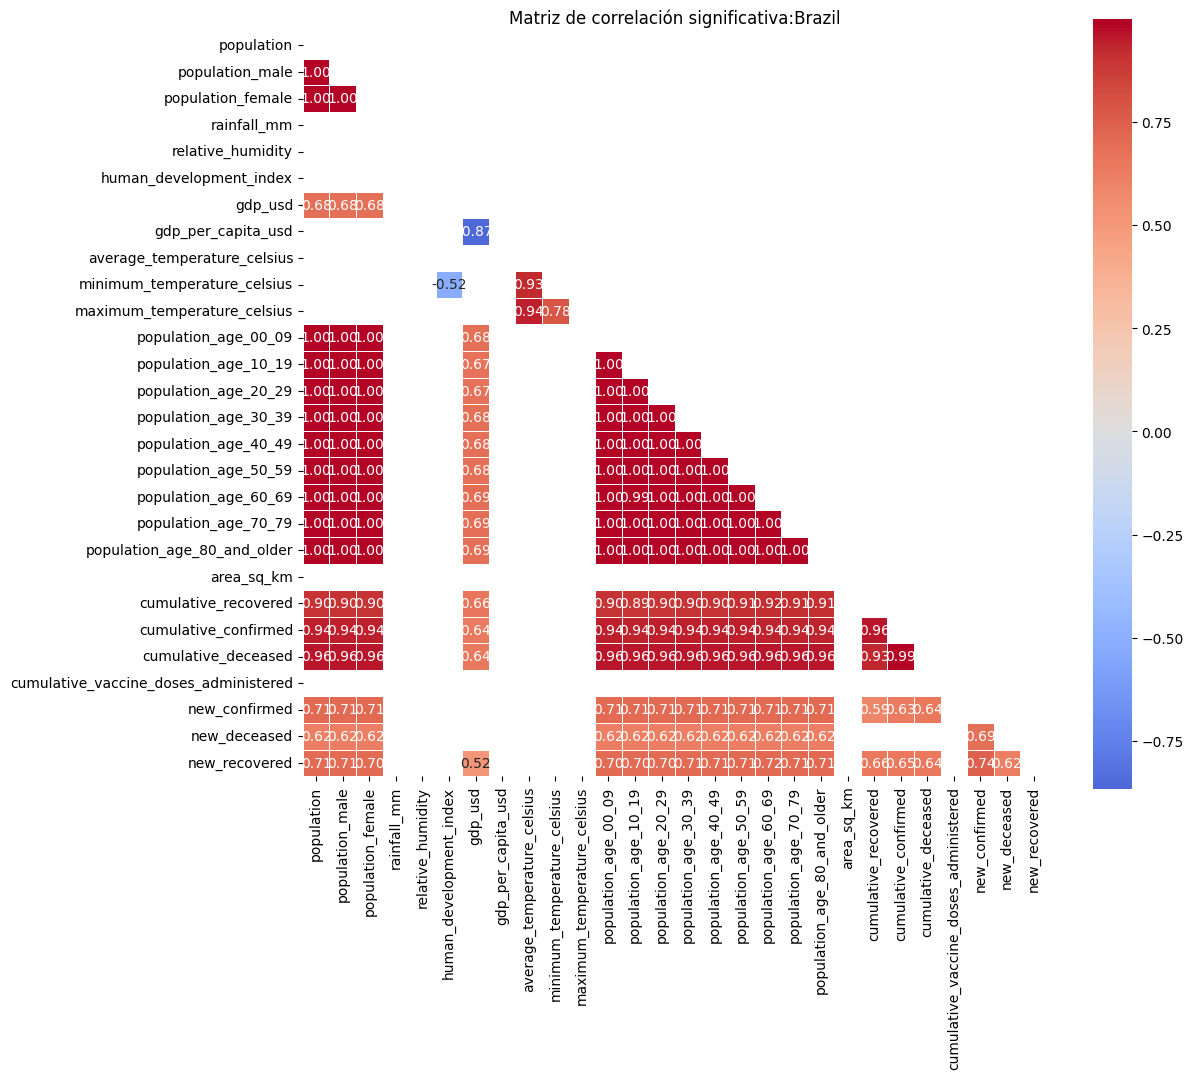

Mapa de calor generado para Brazil con exito.


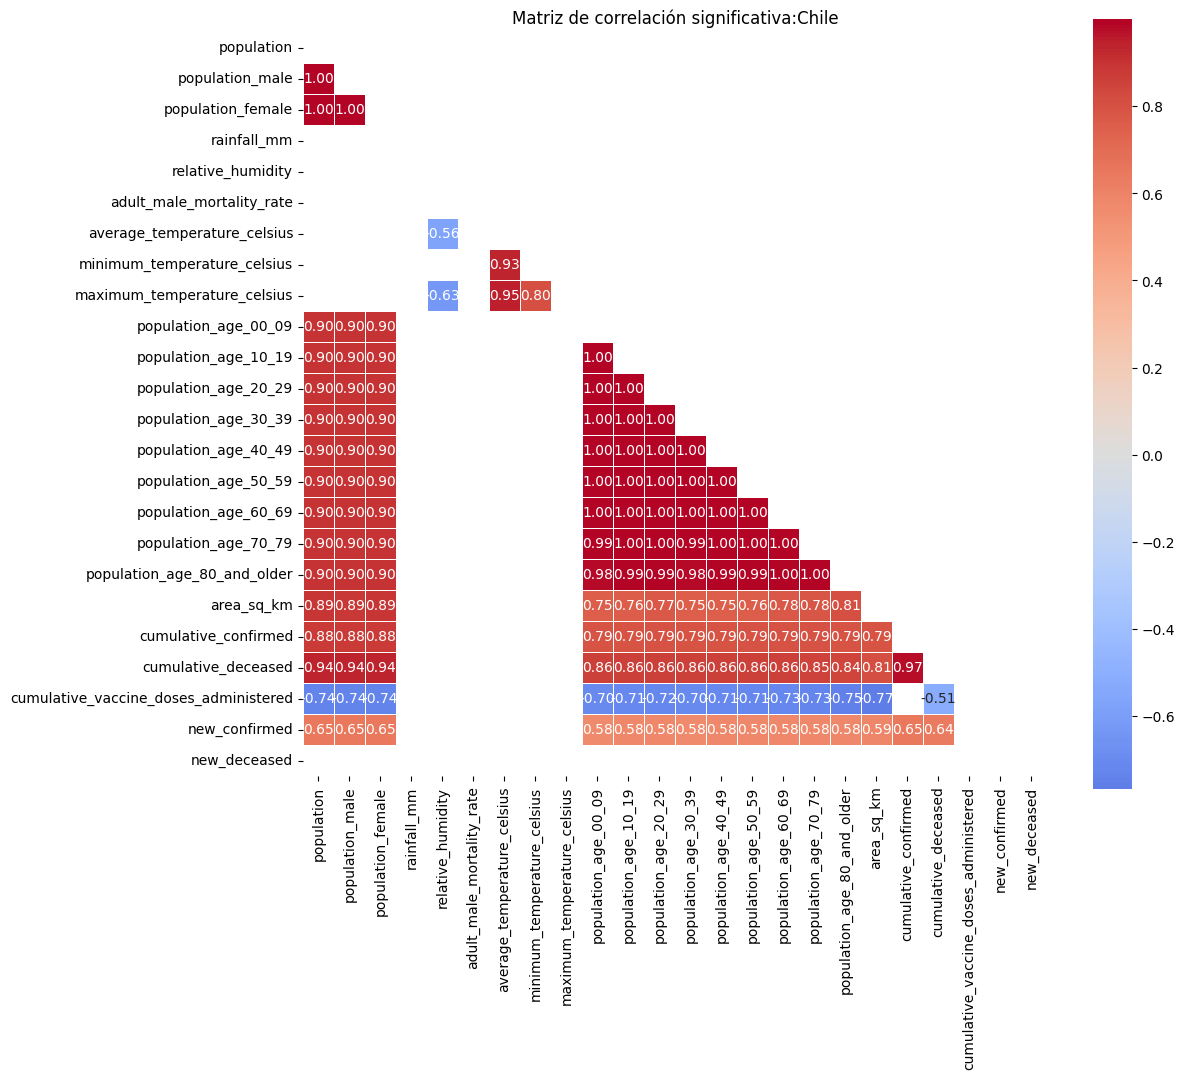

Mapa de calor generado para Chile con exito.


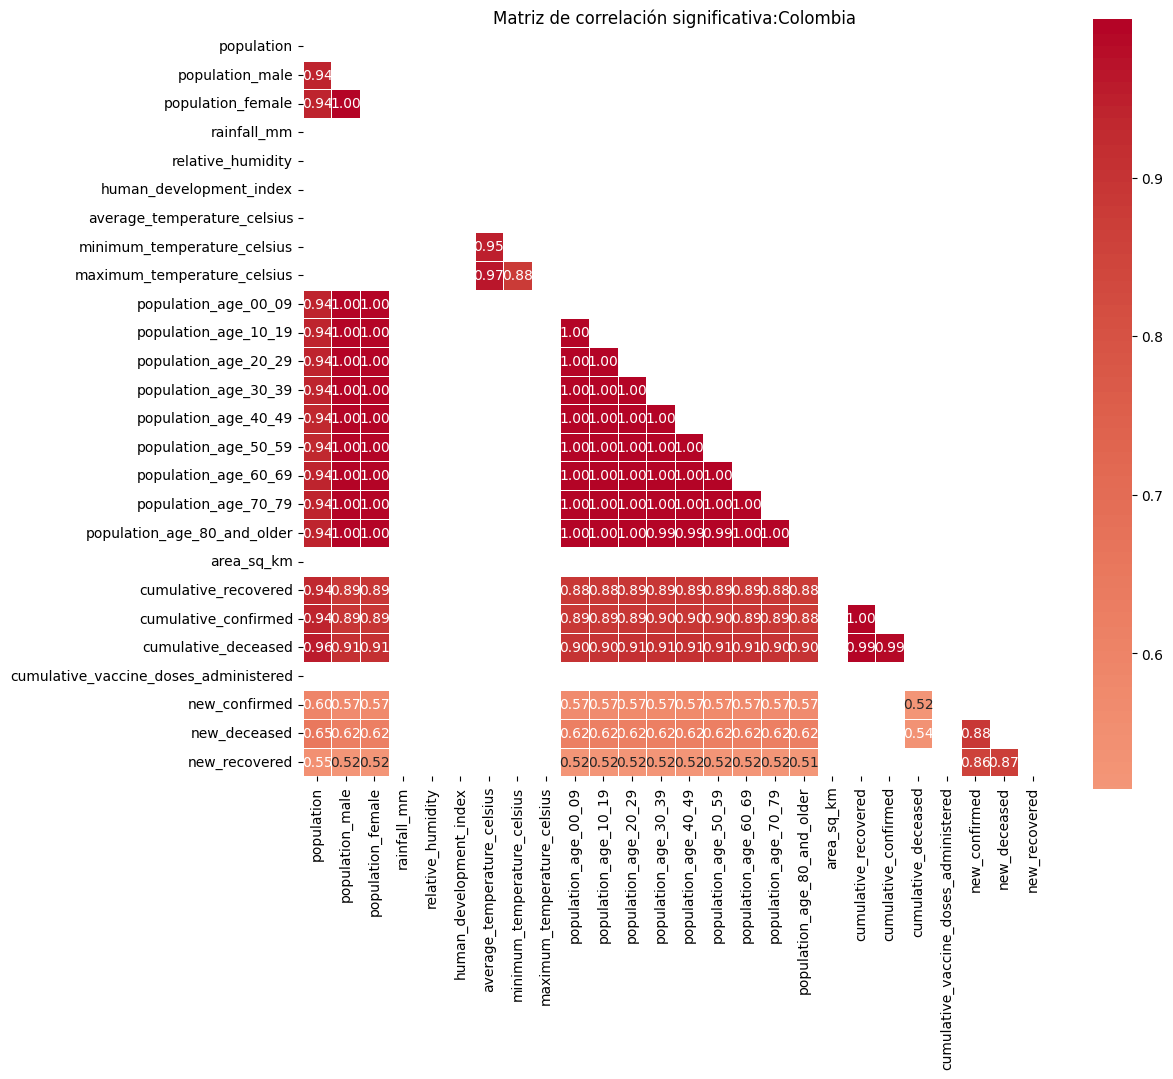

Mapa de calor generado para Colombia con exito.


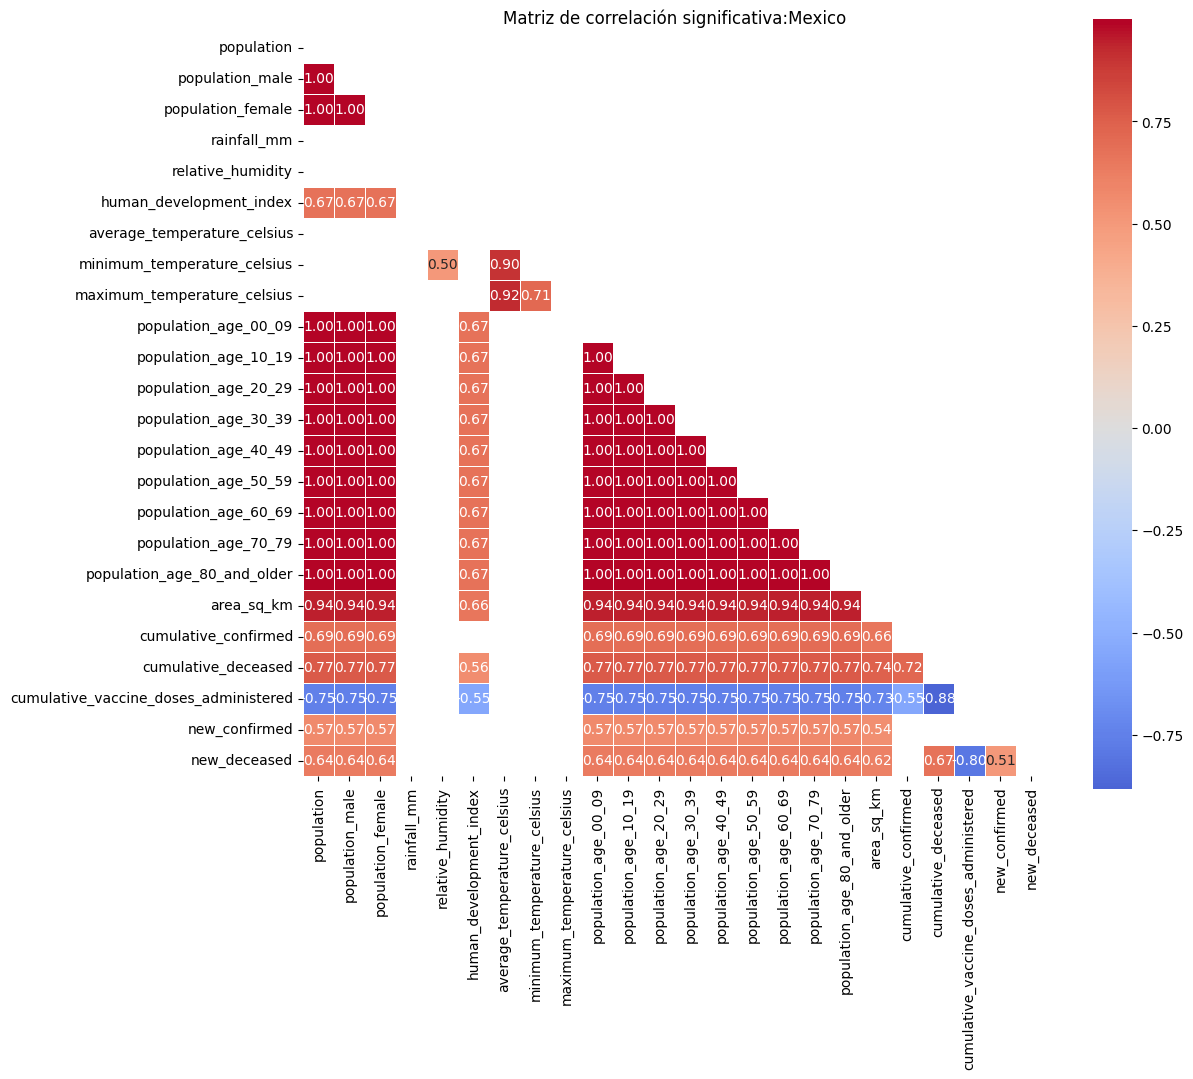

Mapa de calor generado para Mexico con exito.


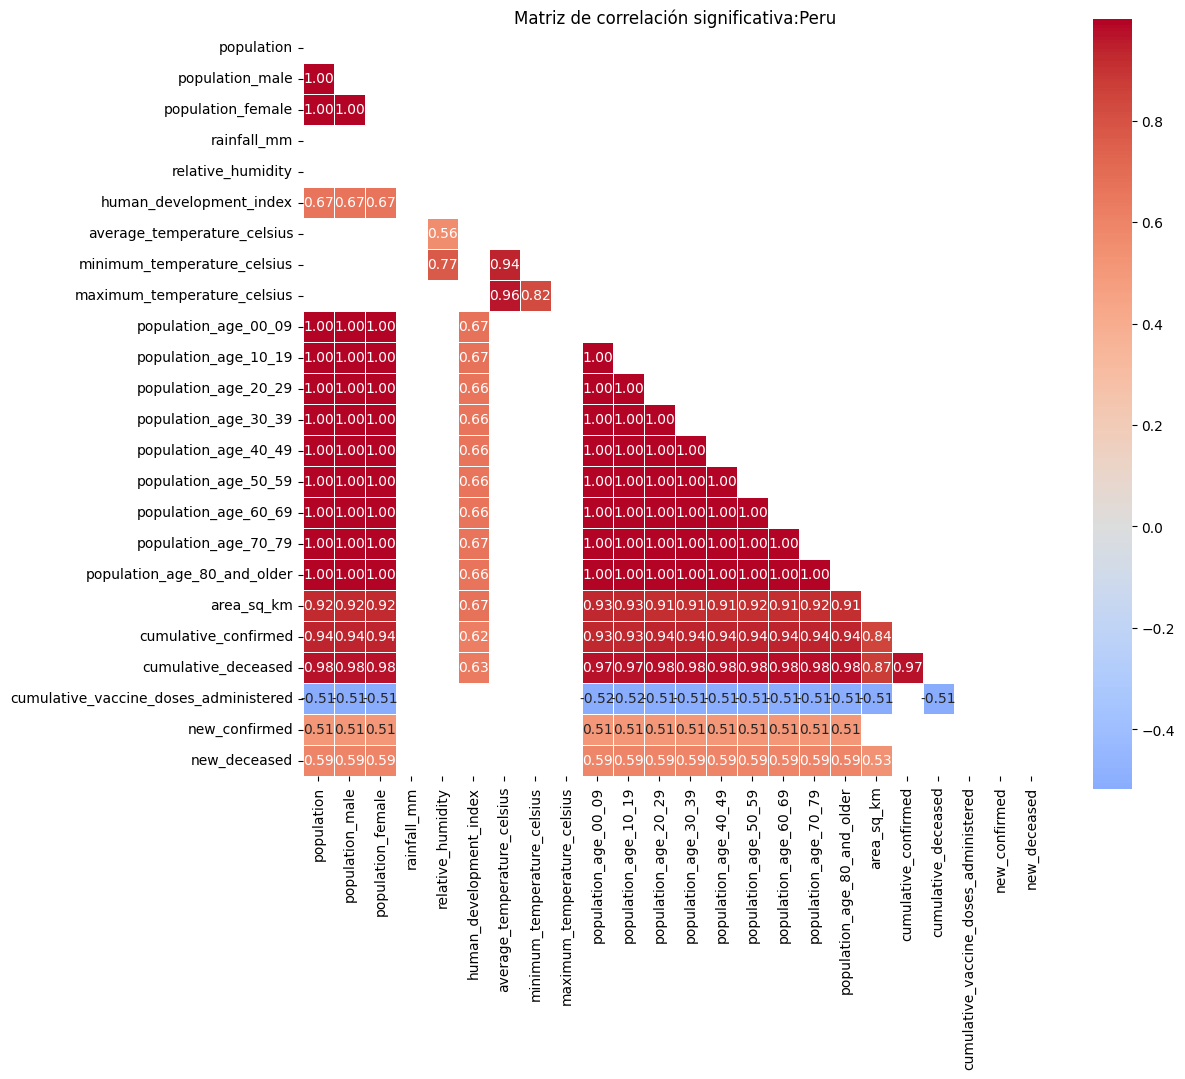

Mapa de calor generado para Peru con exito.


In [22]:
paises=datos_filtrados['country_name'].unique()
variables_mapa=['population','population_male','population_female','population_rural','rainfall_mm','area_urban_sq_km','population_largest_city','area_rural_sq_km','relative_humidity','population_urban','population_density','smoking_prevalence','diabetes_prevalence','human_development_index','gdp_usd','gdp_per_capita_usd','life_expectancy','infant_mortality_rate','adult_male_mortality_rate','adult_female_mortality_rate','pollution_mortality_rate','comorbidity_mortality_rate','nurses_per_1000','physicians_per_1000','average_temperature_celsius','minimum_temperature_celsius','maximum_temperature_celsius','population_age_00_09','population_age_10_19','population_age_20_29','population_age_30_39','population_age_40_49','population_age_50_59','population_age_60_69','population_age_70_79','population_age_80_and_older','area_sq_km','cumulative_recovered','cumulative_confirmed','cumulative_deceased','cumulative_vaccine_doses_administered','new_confirmed','new_deceased','new_recovered']
umbral=0.5
for pais in paises:
    plt.figure(figsize=(12,10))
    datos_pais=datos_filtrados[datos_filtrados['country_name'] == pais][variables_mapa]
    matriz_corr=datos_pais.corr() 
    matriz_sig=matriz_corr[abs(matriz_corr)>= umbral]
    matriz_final=matriz_sig.dropna(how='all', axis=0).dropna(how='all', axis=1)
    if matriz_final.empty:
        print(f"No hay correlaciones significativas para {pais}")
        continue
    mask=np.triu(np.ones_like(matriz_final, dtype=bool))
    sns.heatmap(matriz_final, mask=mask, annot=True, cmap='coolwarm', center=0, fmt=".2f",linewidths=0.5, square=True)
    plt.title(f'Matriz de correlación significativa:{pais}')
    plt.show()
    print(f"Mapa de calor generado para {pais} con exito.")

Los espacios en blanco es porque se esta intentando correlacionar variables que no cambian de valor dentro de un mismo pais(valores constantes), si el valor es constante la desviación es 0, Python se encuentra con una división por 0 y devuelve NaN, el heatmap lo ignora y no lo colorea. (Para obtener otra vista habría que obtener las variables que sí cambian de las fijas o estáticas).

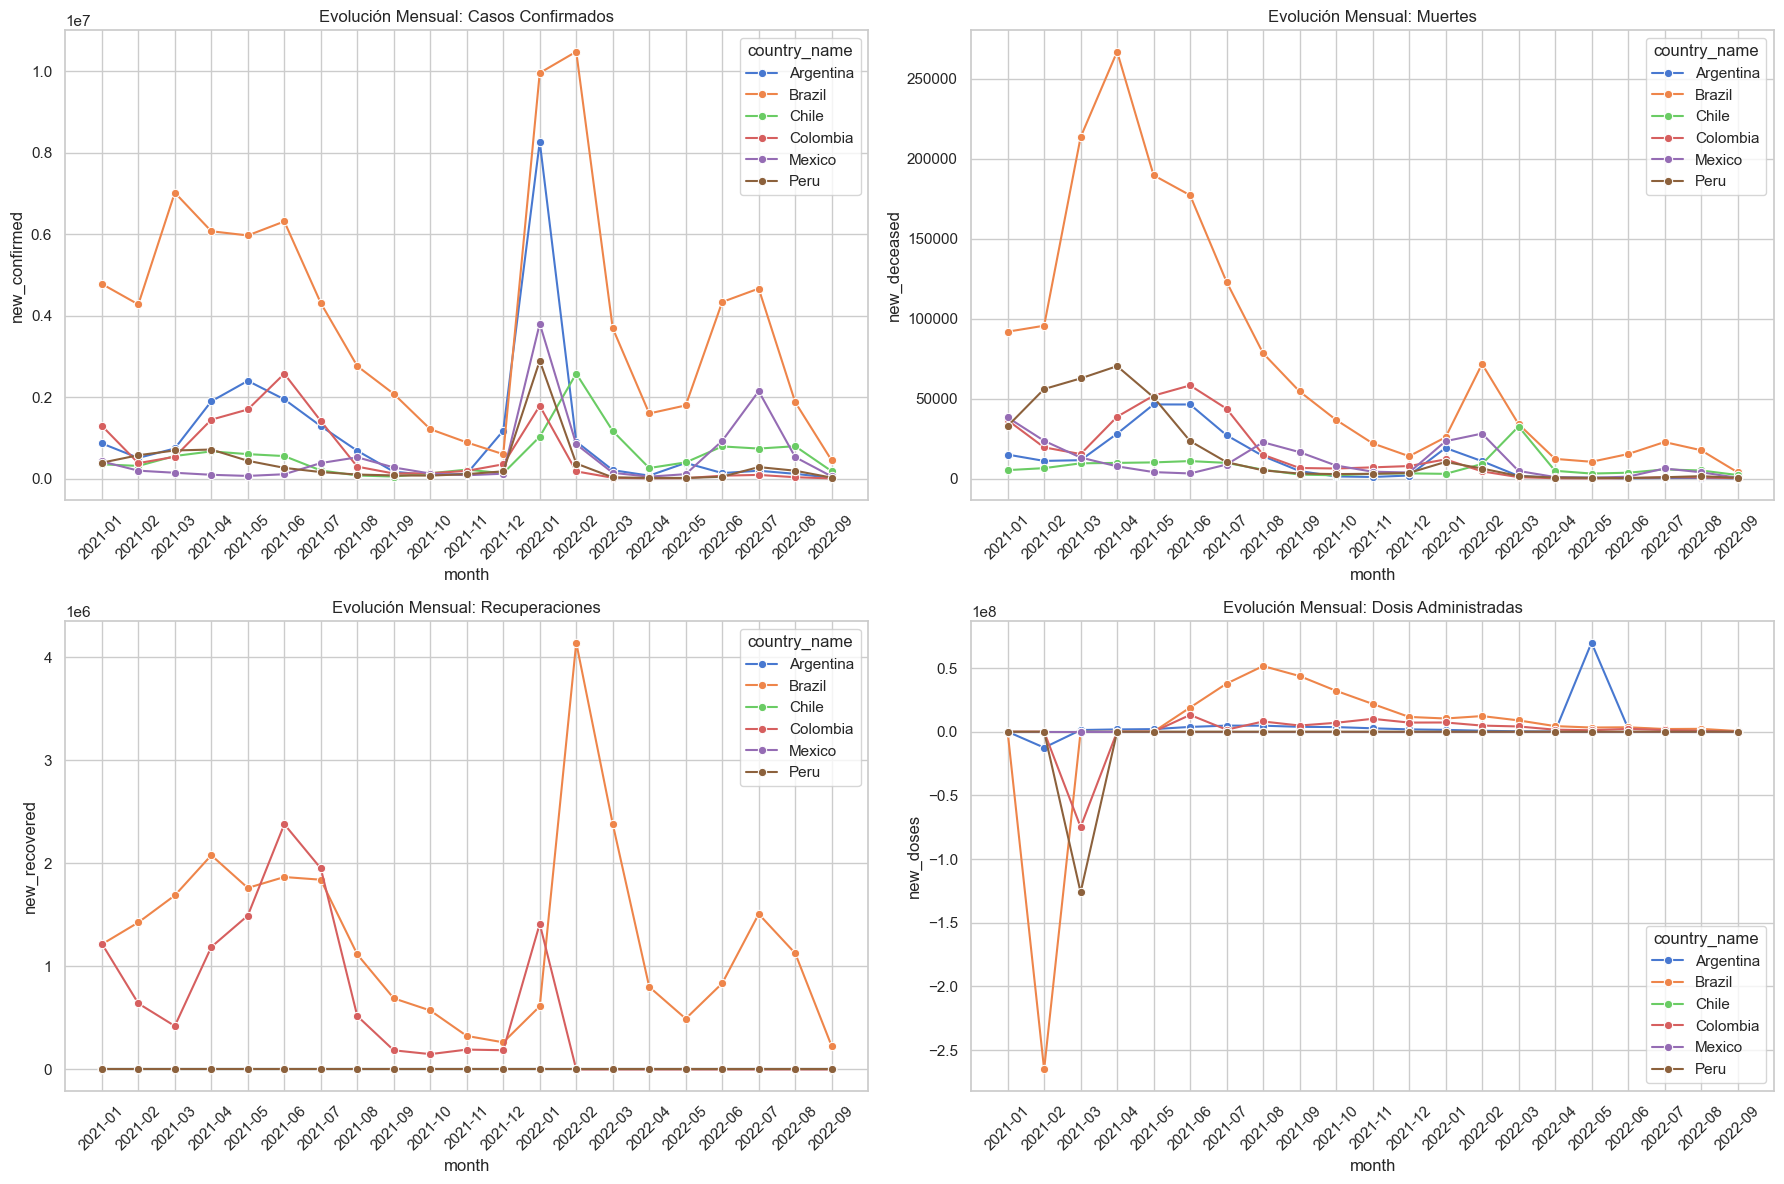

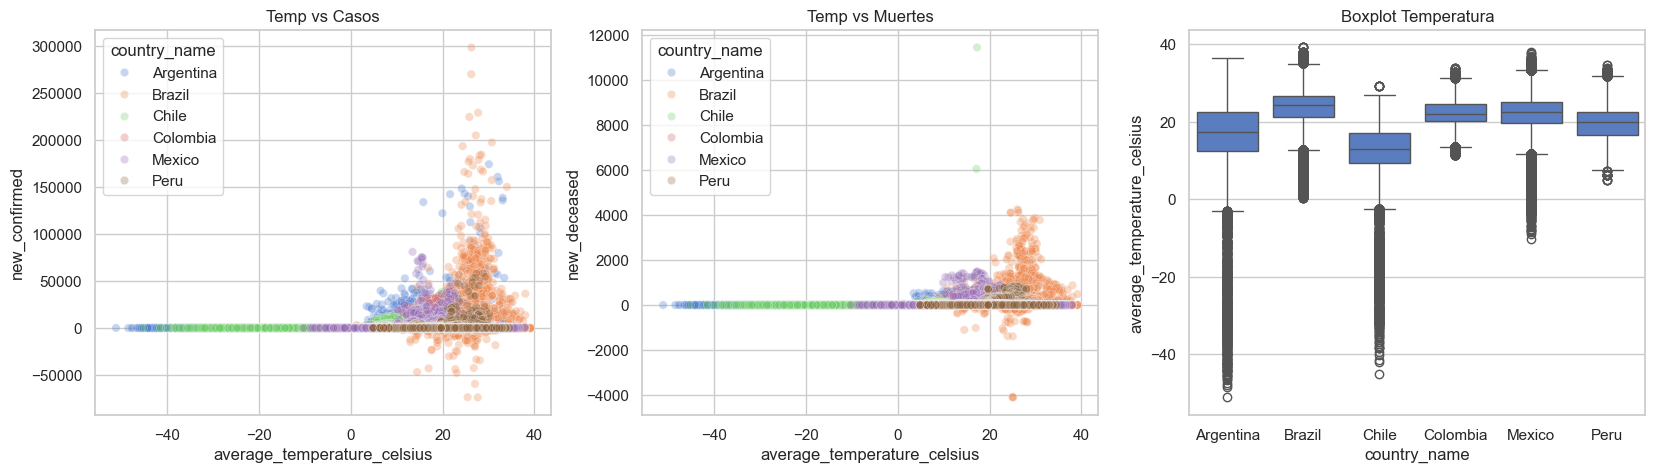

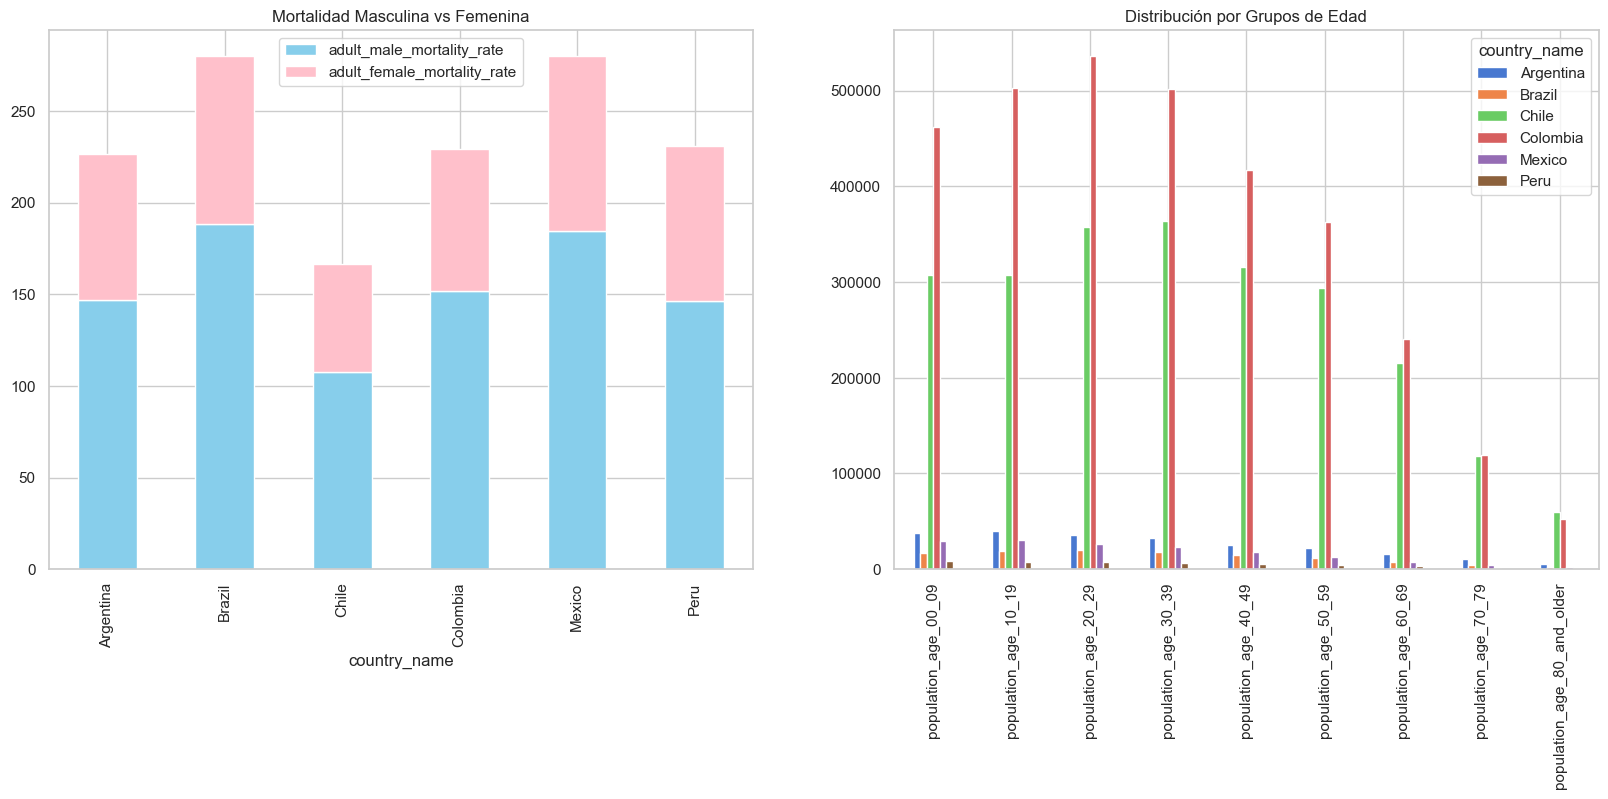

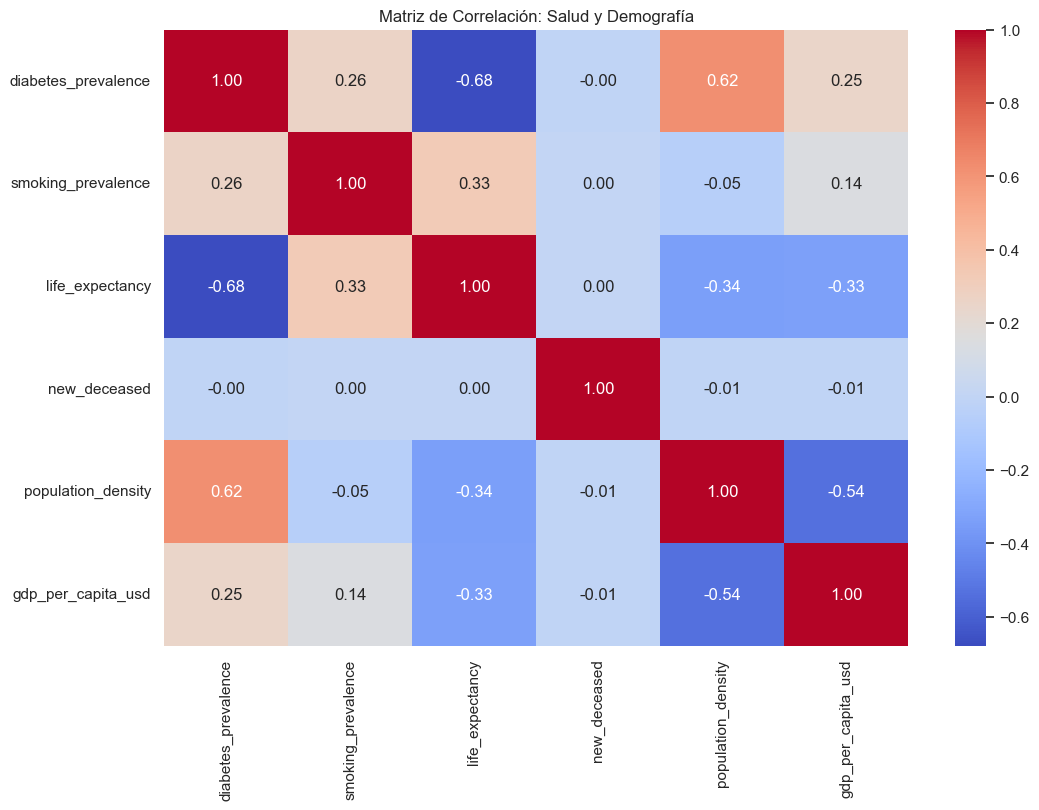

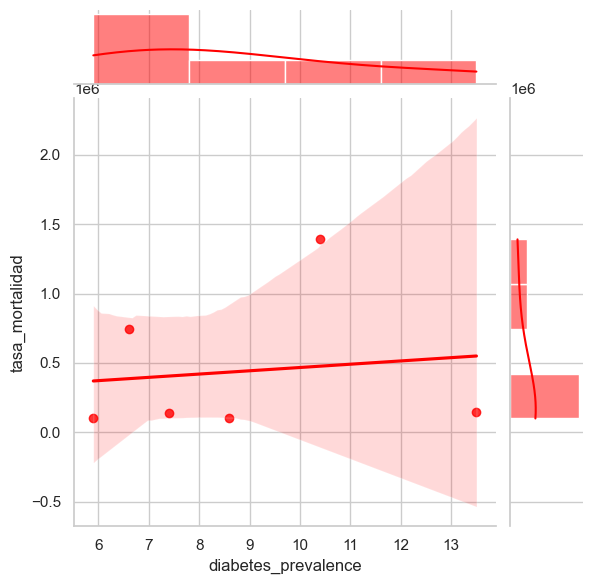

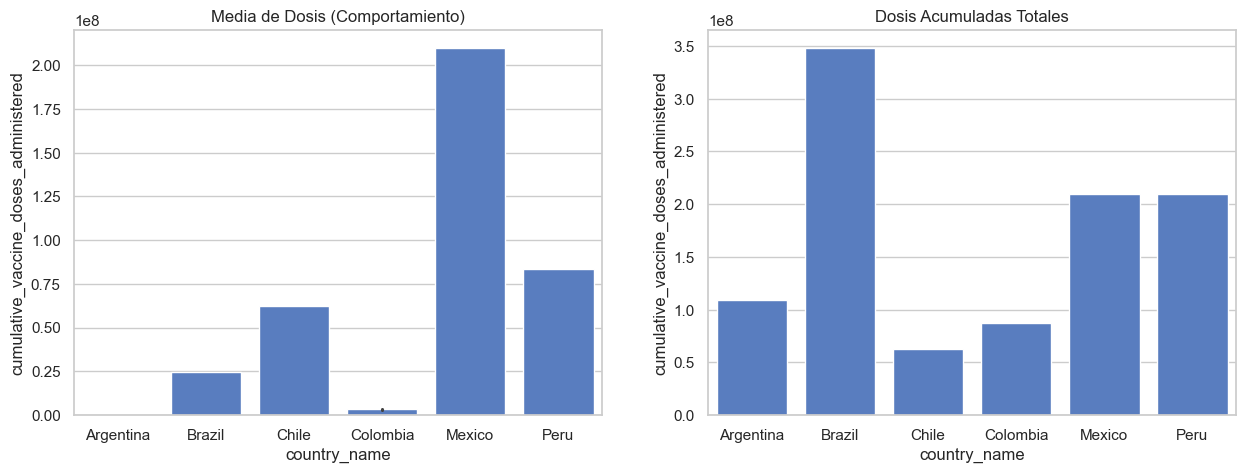

Proceso Finalizado


In [23]:
import warnings

# --- 1. CONFIGURACIÓN DE SEGURIDAD Y VELOCIDAD ---
warnings.filterwarnings('ignore') # Limpia el reporte de avisos técnicos
df = datos_filtrados.copy() # Solución definitiva al SettingWithCopyWarning
df['date'] = pd.to_datetime(df['date'])

# SOLUCIÓN AL KEYERROR: Definición inmediata de variables temporales
df['month'] = df['date'].dt.to_period('M').astype(str)
df['year'] = df['date'].dt.year

# Identificar variables dinámicas (que sí cambian) para Histogramas y Violinplots
vars_num = df.select_dtypes(include=[np.number]).columns
vars_con_cambio = [col for col in vars_num if df[col].nunique() > 1]
cols_edad = [c for c in df.columns if 'population_age' in c]

# --- 2. PRE-PROCESAMIENTO AGRUPADO (Optimización de velocidad) ---
df_mensual = df.groupby(['month', 'country_name']).agg({
    'new_confirmed': 'sum',
    'new_deceased': 'sum',
    'new_recovered': 'sum',
    'cumulative_vaccine_doses_administered': 'max',
    'average_temperature_celsius': 'mean'
}).reset_index()

# Calculamos dosis mensuales por diferencia
df_mensual['new_doses'] = df_mensual.groupby('country_name')['cumulative_vaccine_doses_administered'].diff().fillna(0)

# --- 3. BLOQUE DE GRÁFICOS UNIFICADOS ---
sns.set_theme(style="whitegrid", palette="muted")

# A. EVOLUCIÓN MENSUAL POR PAÍS (Casos, Muertes, Recuperados, Vacunas)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
metricas = ['new_confirmed', 'new_deceased', 'new_recovered', 'new_doses']
titulos = ['Casos Confirmados', 'Muertes', 'Recuperaciones', 'Dosis Administradas']

for i, col in enumerate(metricas):
    ax = axes[i//2, i%2]
    sns.lineplot(data=df_mensual, x='month', y=col, hue='country_name', ax=ax, marker='o')
    ax.set_title(f'Evolución Mensual: {titulos[i]}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# B. ANÁLISIS CLIMÁTICO Y DISPERSIÓN
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(data=df, x='average_temperature_celsius', y='new_confirmed', hue='country_name', ax=axes[0], alpha=0.3).set_title('Temp vs Casos')
sns.scatterplot(data=df, x='average_temperature_celsius', y='new_deceased', hue='country_name', ax=axes[1], alpha=0.3).set_title('Temp vs Muertes')
sns.boxplot(data=df, x='country_name', y='average_temperature_celsius', ax=axes[2]).set_title('Boxplot Temperatura')
plt.show()

# C. DEMOGRAFÍA Y SALUD (Barras Apiladas y Edad)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
# Mortalidad Género
df.groupby('country_name')[['adult_male_mortality_rate', 'adult_female_mortality_rate']].mean().plot(kind='bar', stacked=True, ax=ax1, color=['skyblue', 'pink'])
ax1.set_title('Mortalidad Masculina vs Femenina')
# Distribución Edad
df.groupby('country_name')[cols_edad].mean().T.plot(kind='bar', ax=ax2)
ax2.set_title('Distribución por Grupos de Edad')
plt.show()


# E. MATRIZ DE CORRELACIÓN Y DIABETES
plt.figure(figsize=(12, 8))
cols_corr = ['diabetes_prevalence', 'smoking_prevalence', 'life_expectancy', 'new_deceased', 'population_density', 'gdp_per_capita_usd']
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f").set_title('Matriz de Correlación: Salud y Demografía')
plt.show()

# Diabetes vs Mortalidad (Normalizado por población)
df_final = df.groupby('country_name').agg({'diabetes_prevalence':'mean', 'new_deceased':'sum', 'population':'mean'})
df_final['tasa_mortalidad'] = (df_final['new_deceased'] / df_final['population']) * 100000
sns.jointplot(data=df_final, x='diabetes_prevalence', y='tasa_mortalidad', kind='reg', color='red')
plt.show()

# F. RESUMEN VACUNACIÓN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=df, x='country_name', y='cumulative_vaccine_doses_administered', estimator=np.mean, ax=ax1).set_title('Media de Dosis (Comportamiento)')
sns.barplot(data=df, x='country_name', y='cumulative_vaccine_doses_administered', estimator=np.max, ax=ax2).set_title('Dosis Acumuladas Totales')
plt.show()

print("Proceso Finalizado")



Avance 3

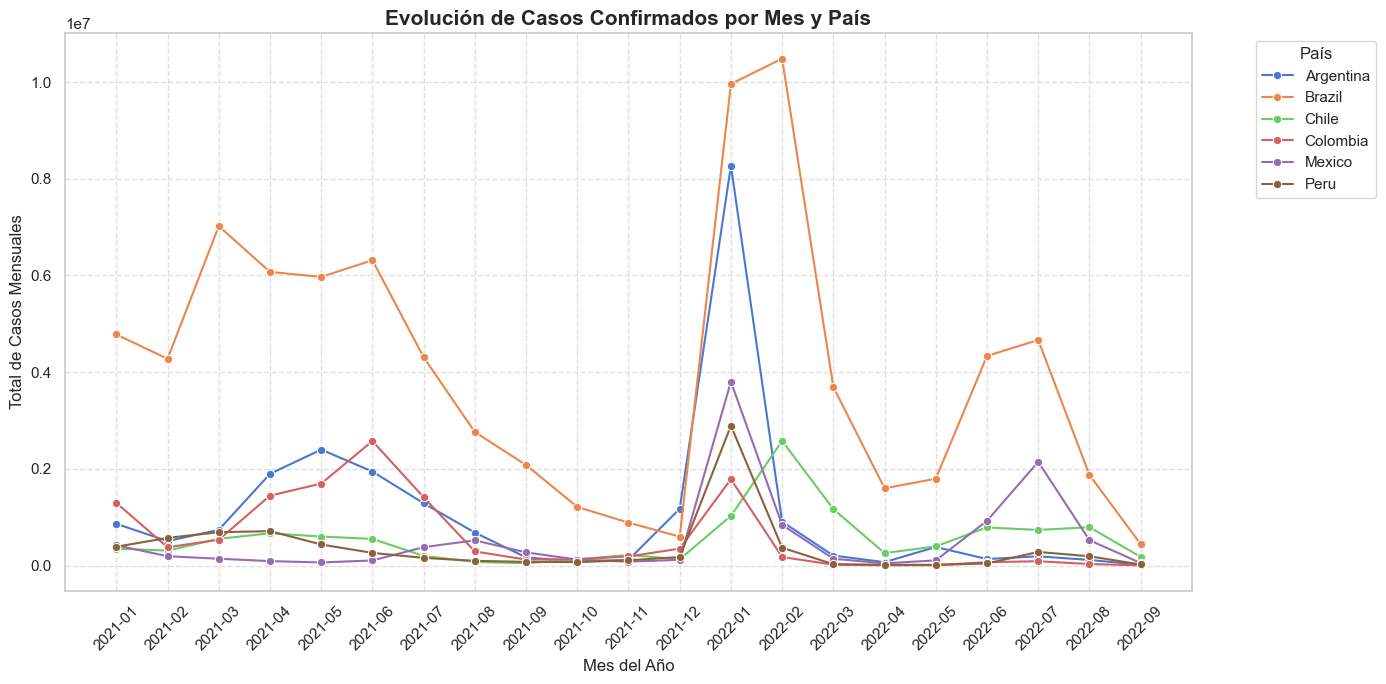

In [24]:
# 1. Aseguramos que la columna 'date' sea de tipo datetime
datos_filtrados['date'] = pd.to_datetime(datos_filtrados['date'])

# 2. Creamos una columna de 'Mes' para agrupar (Formato YYYY-MM)
datos_filtrados['month'] = datos_filtrados['date'].dt.to_period('M')

# 3. Agrupamos por país y mes, sumando los casos confirmados
# Usamos .astype(str) al final para que Matplotlib pueda graficar el periodo sin errores
evolucion_mensual = datos_filtrados.groupby(['month', 'country_name'])['new_confirmed'].sum().reset_index()
evolucion_mensual['month'] = evolucion_mensual['month'].astype(str)

# 4. Graficamos en un solo lienzo para comparar magnitudes y tendencias
plt.figure(figsize=(14, 7))
sns.lineplot(data=evolucion_mensual, x='month', y='new_confirmed', hue='country_name', marker='o')

plt.title('Evolución de Casos Confirmados por Mes y País', fontsize=15, fontweight='bold')
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Total de Casos Mensuales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


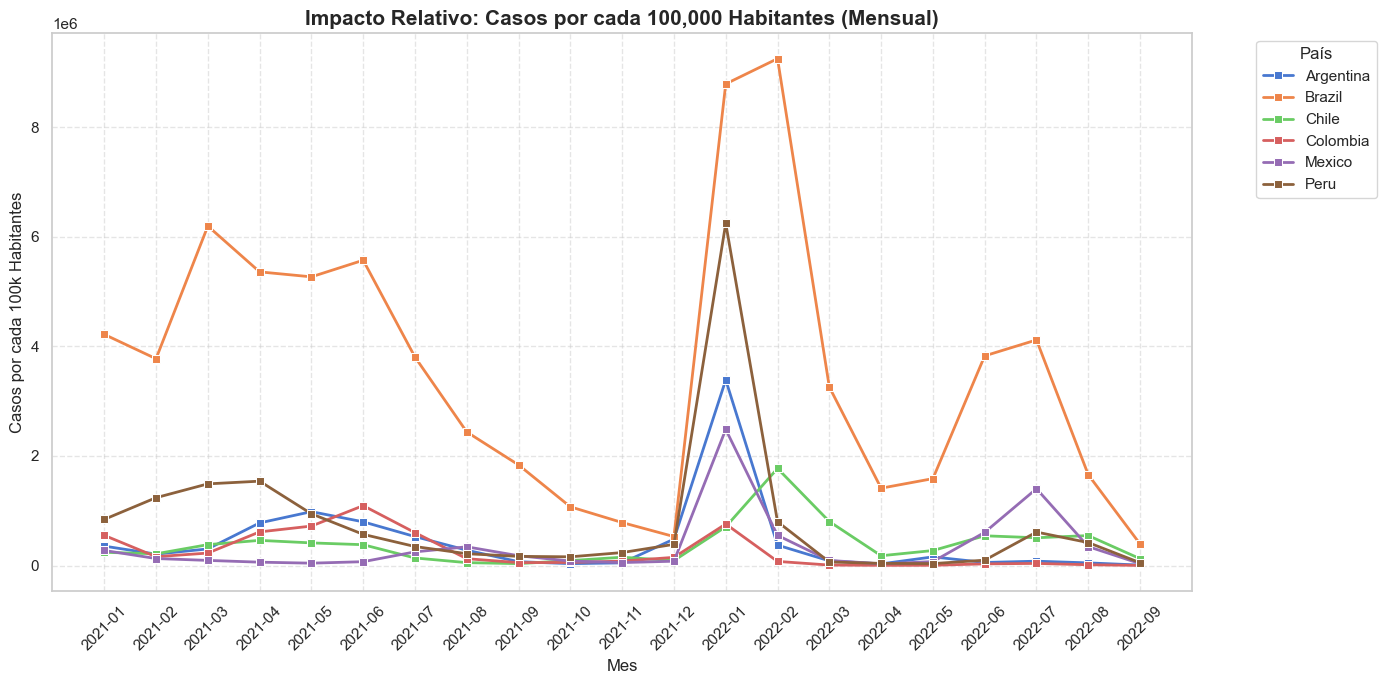

In [25]:
# 1. Agrupamos casos y obtenemos la población media por país (que es constante)
df_mensual_tasa = datos_filtrados.groupby(['month', 'country_name']).agg({
    'new_confirmed': 'sum',
    'population': 'mean'
}).reset_index()

# 2. Calculamos la Tasa Normalizada (Casos por cada 100,000 personas)
# Esto es lo que estadísticamente permite comparar el impacto real
df_mensual_tasa['tasa_100k'] = (df_mensual_tasa['new_confirmed'] / df_mensual_tasa['population']) * 100000
df_mensual_tasa['month'] = df_mensual_tasa['month'].astype(str)

# 3. Graficado comparativo de impacto relativo
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_mensual_tasa, x='month', y='tasa_100k', hue='country_name', marker='s', linewidth=2)

plt.title('Impacto Relativo: Casos por cada 100,000 Habitantes (Mensual)', fontsize=15, fontweight='bold')
plt.ylabel('Casos por cada 100k Habitantes', fontsize=12)
plt.xlabel('Mes', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


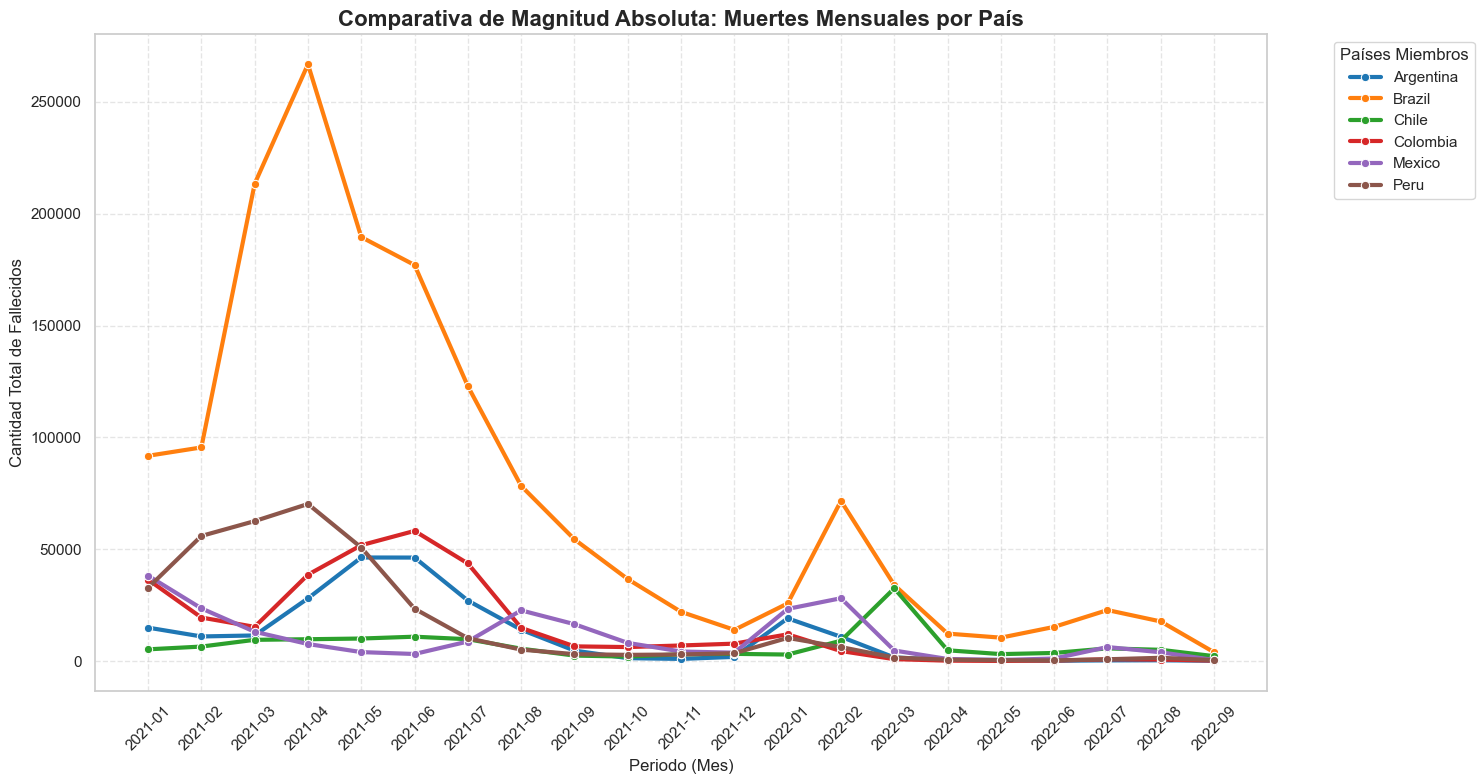

In [26]:
# 1. Agrupación por mes y país (Suma de muertes reales)
df_muertes_comp = datos_filtrados.groupby(['month', 'country_name'])['new_deceased'].sum().reset_index()
df_muertes_comp['month'] = df_muertes_comp['month'].astype(str)

# 2. Gráfico de Magnitud Total
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_muertes_comp, x='month', y='new_deceased', hue='country_name', 
             marker='o', linewidth=3, palette='tab10')

# 3. Formato para presentación ejecutiva
plt.title('Comparativa de Magnitud Absoluta: Muertes Mensuales por País', fontsize=16, fontweight='bold')
plt.xlabel('Periodo (Mes)', fontsize=12)
plt.ylabel('Cantidad Total de Fallecidos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Países Miembros', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

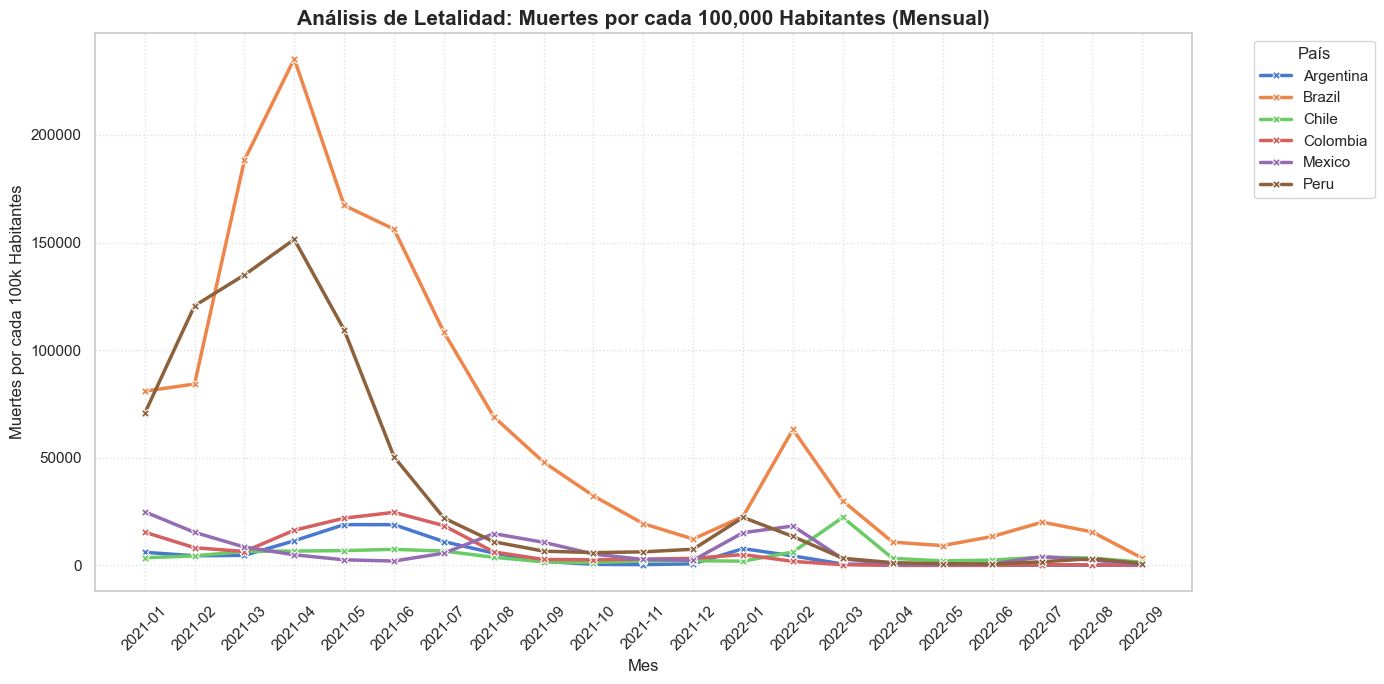

In [27]:
# 1. Agrupamos muertes y población media por mes y país
df_muertes_tasa = datos_filtrados.groupby(['month', 'country_name']).agg({
    'new_deceased': 'sum',
    'population': 'mean'
}).reset_index()

# 2. Calculamos la Tasa de Mortalidad Normalizada
df_muertes_tasa['tasa_muertes_100k'] = (df_muertes_tasa['new_deceased'] / df_muertes_tasa['population']) * 100000
df_muertes_tasa['month'] = df_muertes_tasa['month'].astype(str)

# 3. Graficado comparativo
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_muertes_tasa, x='month', y='tasa_muertes_100k', hue='country_name', marker='X', linewidth=2.5)

plt.title('Análisis de Letalidad: Muertes por cada 100,000 Habitantes (Mensual)', fontsize=15, fontweight='bold')
plt.ylabel('Muertes por cada 100k Habitantes', fontsize=12)
plt.xlabel('Mes', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()


De toda la población, ¿Cuántos murieron?

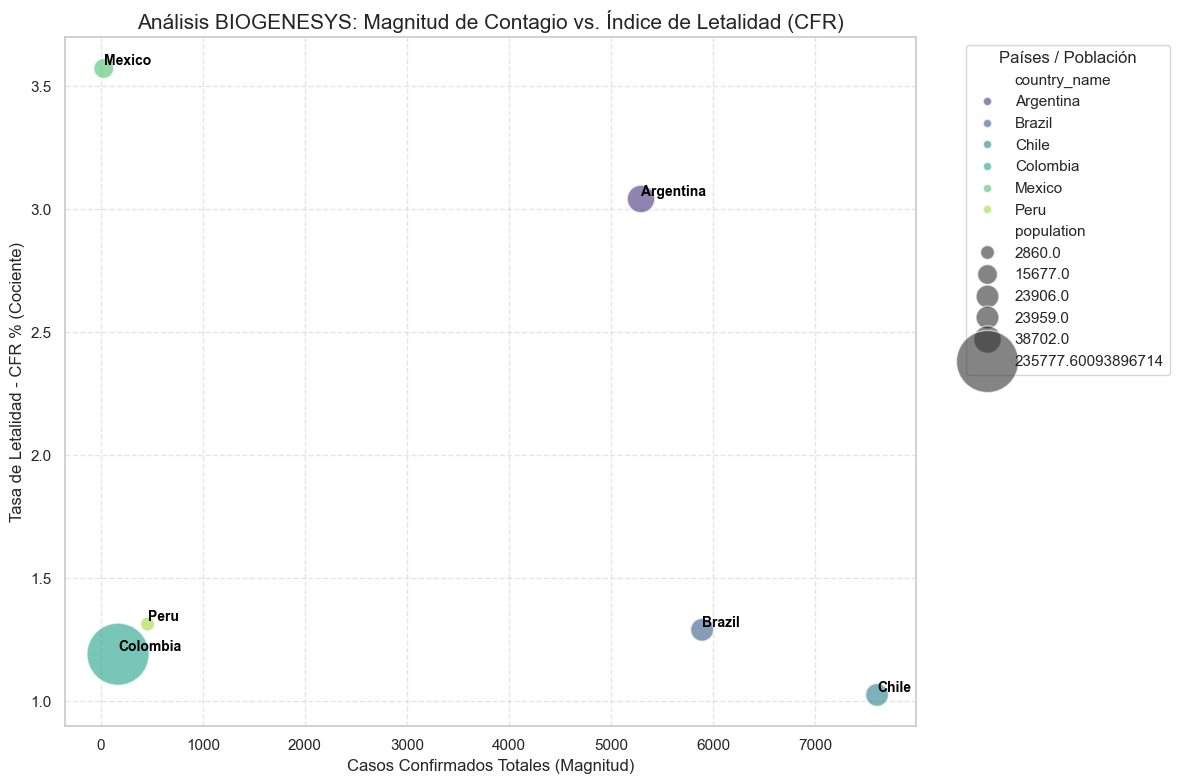

In [45]:
# 1. Preparación de los datos (Usamos el último registro de cada país para tener el total)
# Asumiendo que tu dataset ya tiene las columnas que calculamos: 'cfr' y 'cumulative_confirmed'
df_final = datos_filtrados.sort_values('date').groupby('country_name').last().reset_index()
df_final['cfr']=(df_final['cumulative_deceased']/df_final['cumulative_confirmed'])*100

# 2. Crear el gráfico
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Dibujamos las burbujas
scatter = sns.scatterplot(
    data=df_final, 
    x='cumulative_confirmed', 
    y='cfr', 
    size='population', 
    hue='country_name',
    sizes=(100, 2000), # Tamaño de las burbujas
    alpha=0.6,
    palette='viridis'
)

# 3. Etiquetas de los países (Para identificar quién es quién)
for i in range(df_final.shape[0]):
    plt.text(
        df_final.cumulative_confirmed.iloc[i], 
        df_final.cfr.iloc[i], # Un poco arriba del punto
        df_final.country_name.iloc[i], 
        fontsize=10, ha='left', va='bottom', weight='bold', color='black'
    )

# 4. Personalización técnica
plt.title('Análisis BIOGENESYS: Magnitud de Contagio vs. Índice de Letalidad (CFR)', fontsize=15)
plt.xlabel('Casos Confirmados Totales (Magnitud)', fontsize=12)
plt.ylabel('Tasa de Letalidad - CFR % (Cociente)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Mover la leyenda afuera
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Países / Población')

plt.tight_layout()
plt.show()


Letalidad (CFR %)-De los enfermos, que % murió.
A partir de este gráfico podemos separar la magnitud (el tamaño del problema) de la letalidad(la gravedad del problema). México tiene la tasa de letalidad más añta del grupo (aprox=3.6). Esto indica que, aunque no tiene tantos casos como brasil, la probabilidad de morir al contagiarse fue mucho mayor en este país. Brazil y Chile indican una magnitud de contagio masiva, pero están en la parte inferior del eje Y, sus sistemas de salud o su estrategia de vacunación lograron que el volumen masivo de enfermos no se tradujerá en una mortalidad proporcionalmente alta. Argentina tiene una letalidad considerable (3%) sin llegar a niveles de contagio masivo, lo que sugiere una vulnerabilidad activa. Colombia y Perú tienen baja magnitud relativa, lo que indica un manejo estable de la pandemia.

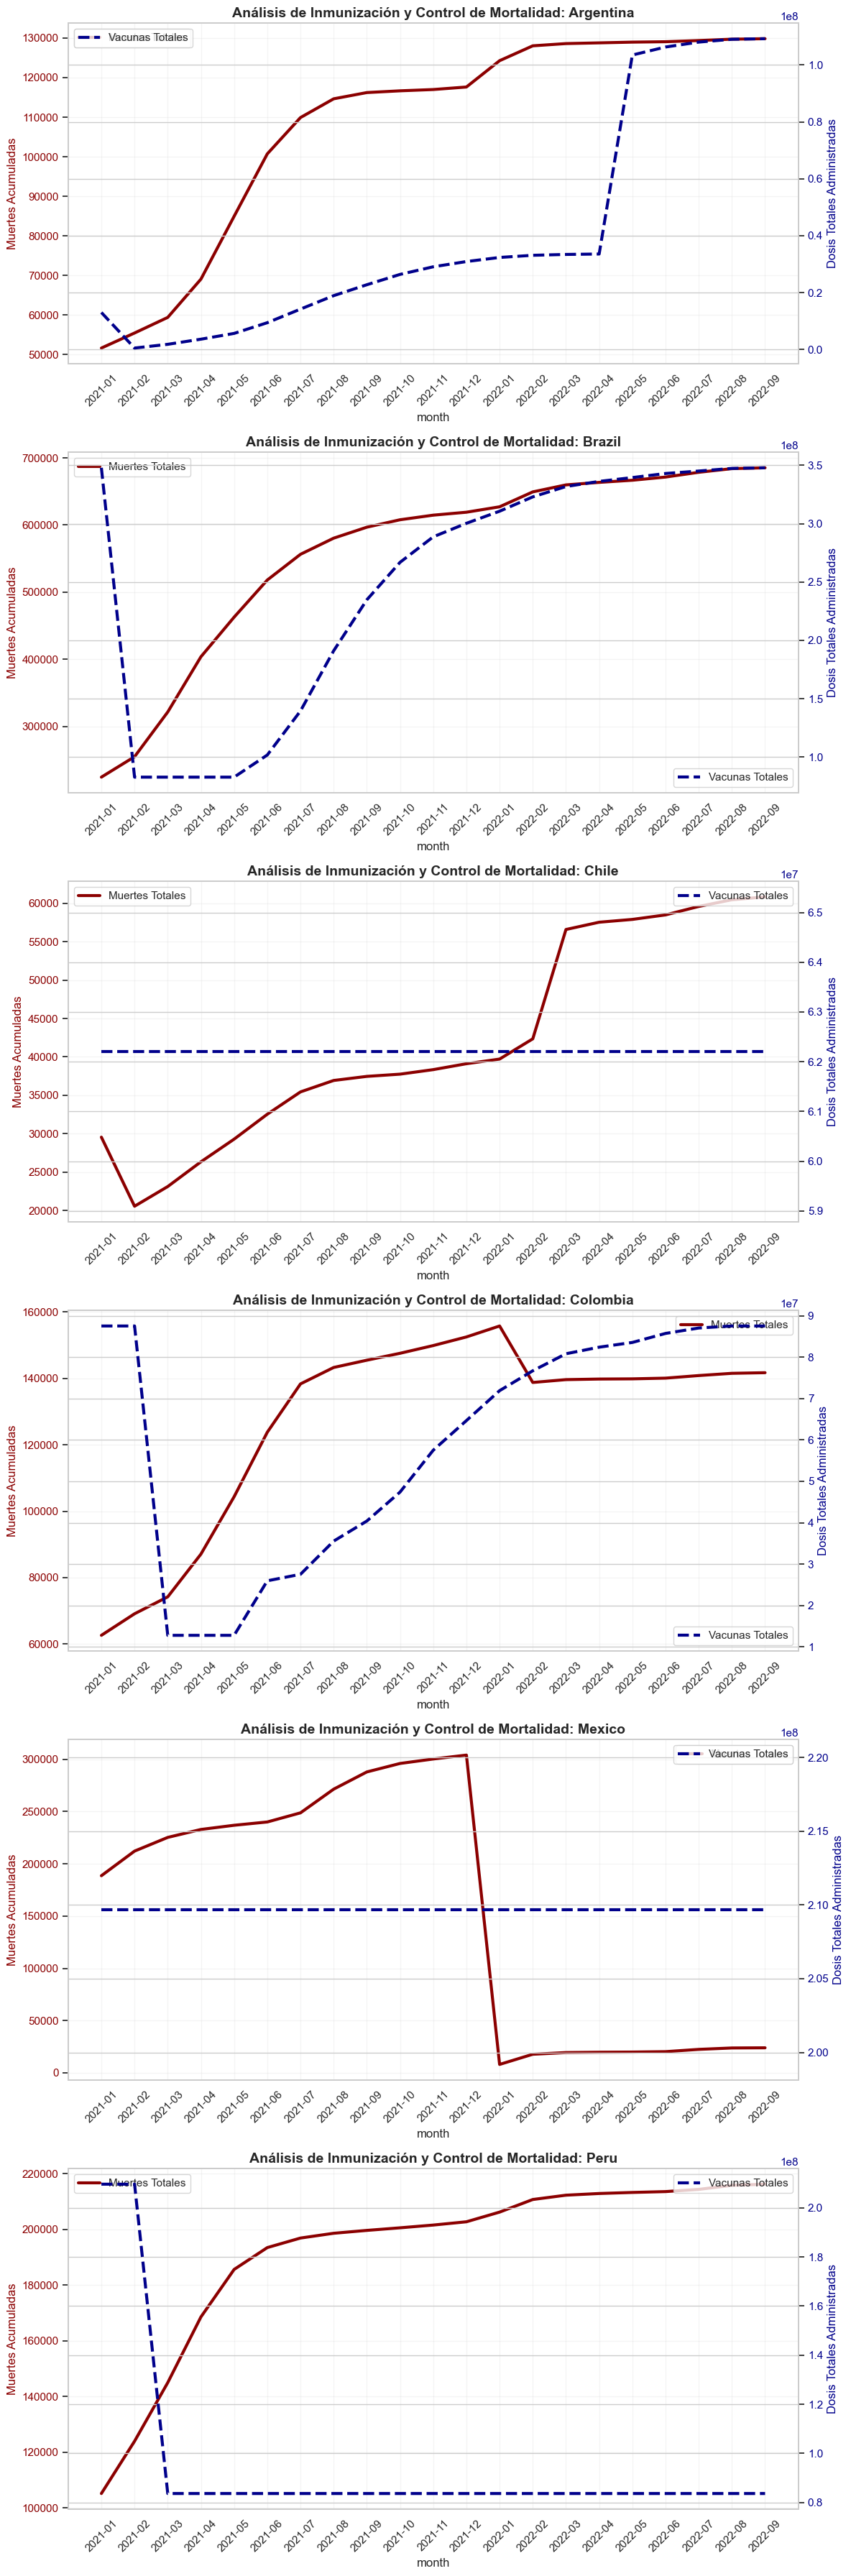

In [28]:
# 1. Agrupamos por mes para obtener el máximo acumulado alcanzado en cada periodo
df_acumulado = datos_filtrados.groupby(['month', 'country_name']).agg({
    'cumulative_deceased': 'max',
    'cumulative_vaccine_doses_administered': 'max'
}).reset_index()

df_acumulado['month'] = df_acumulado['month'].astype(str)
paises = df_acumulado['country_name'].unique()

# 2. Generamos el lienzo comparativo
fig, axes = plt.subplots(nrows=len(paises), ncols=1, figsize=(12, 6 * len(paises)))
if len(paises) == 1: axes = [axes]

for i, pais in enumerate(paises):
    df_p = df_acumulado[df_acumulado['country_name'] == pais]
    
    # Eje Izquierdo: Muertes Acumuladas
    ax1 = axes[i]
    sns.lineplot(data=df_p, x='month', y='cumulative_deceased', ax=ax1, color='darkred', label='Muertes Totales', linewidth=3)
    ax1.set_ylabel('Muertes Acumuladas', color='darkred', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='darkred')
    
    # Eje Derecho: Vacunas Acumuladas
    ax2 = ax1.twinx()
    sns.lineplot(data=df_p, x='month', y='cumulative_vaccine_doses_administered', ax=ax2, color='darkblue', label='Vacunas Totales', linestyle='--', linewidth=3)
    ax2.set_ylabel('Dosis Totales Administradas', color='darkblue', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='darkblue')
    
    ax1.set_title(f'Análisis de Inmunización y Control de Mortalidad: {pais}', fontsize=14, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


Argentina: las muertes se detienen casi en seco justo después del pico masivo de vacunación en 2022.
Brasil: logró vacunar a una escala masiva (3.5e8 dosis), lo que estabilizó una curva de mortalidad que venía fuera de control.
Para México y Chile se observan tramos donde la línea azul se mantiene perfectamente horizontal. Realizé una imputación de datos ffill (relleno hacia adelante). Esto se debe a que los países no siempre reportan las dosis aplicadas de manera diaria, la línea horizontal no significa necesariamente que no se vacunó, indica que el valor reportado se mantuvo constante.

In [29]:
%matplotlib inline

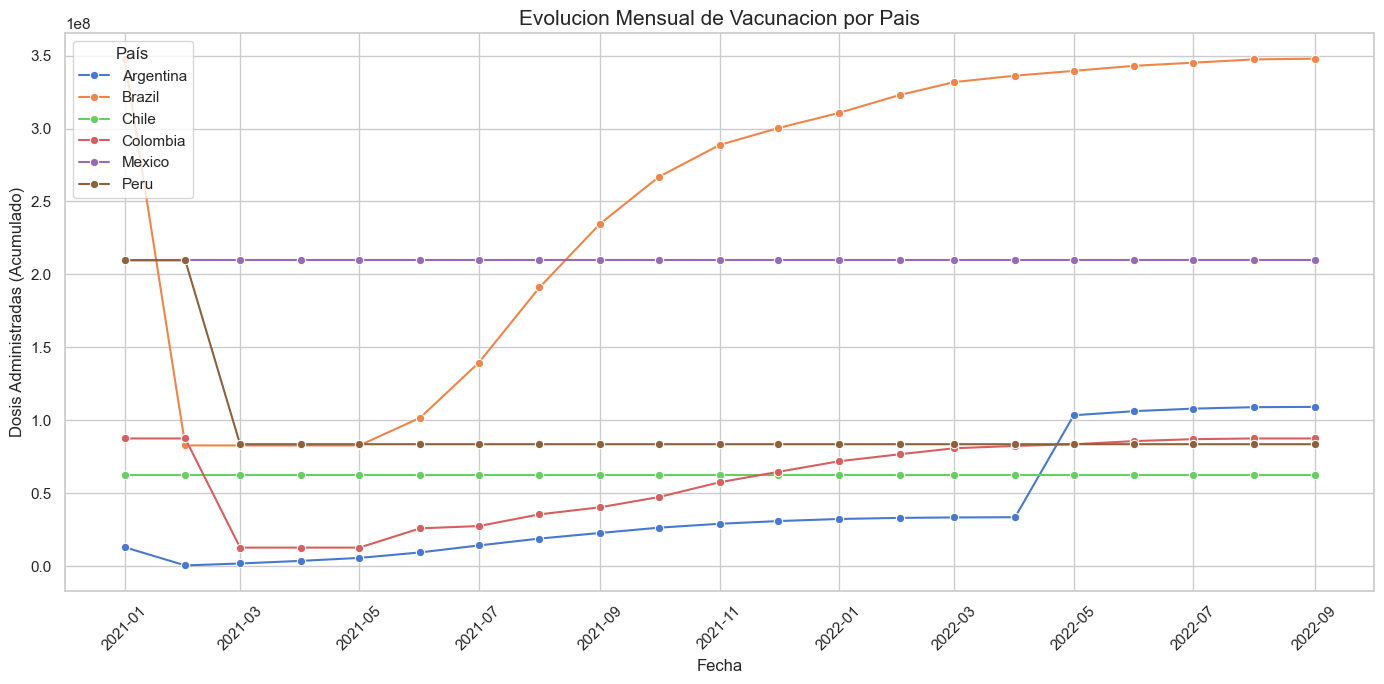

In [30]:
datos_filtrados['date']=pd.to_datetime(datos_filtrados['date'])
datos_filtrados['mes_año']=datos_filtrados['date'].dt.to_period('M').dt.to_timestamp()
df_vacunacion=datos_filtrados.groupby(['country_name','mes_año'])['cumulative_vaccine_doses_administered'].max().reset_index()
plt.figure(figsize=(14,7))
sns.set_style("whitegrid")
sns.lineplot(data=df_vacunacion, x='mes_año', y='cumulative_vaccine_doses_administered', hue='country_name', marker='o')
plt.title('Evolucion Mensual de Vacunacion por Pais', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Dosis Administradas (Acumulado)', fontsize=12)
plt.legend(title='País')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

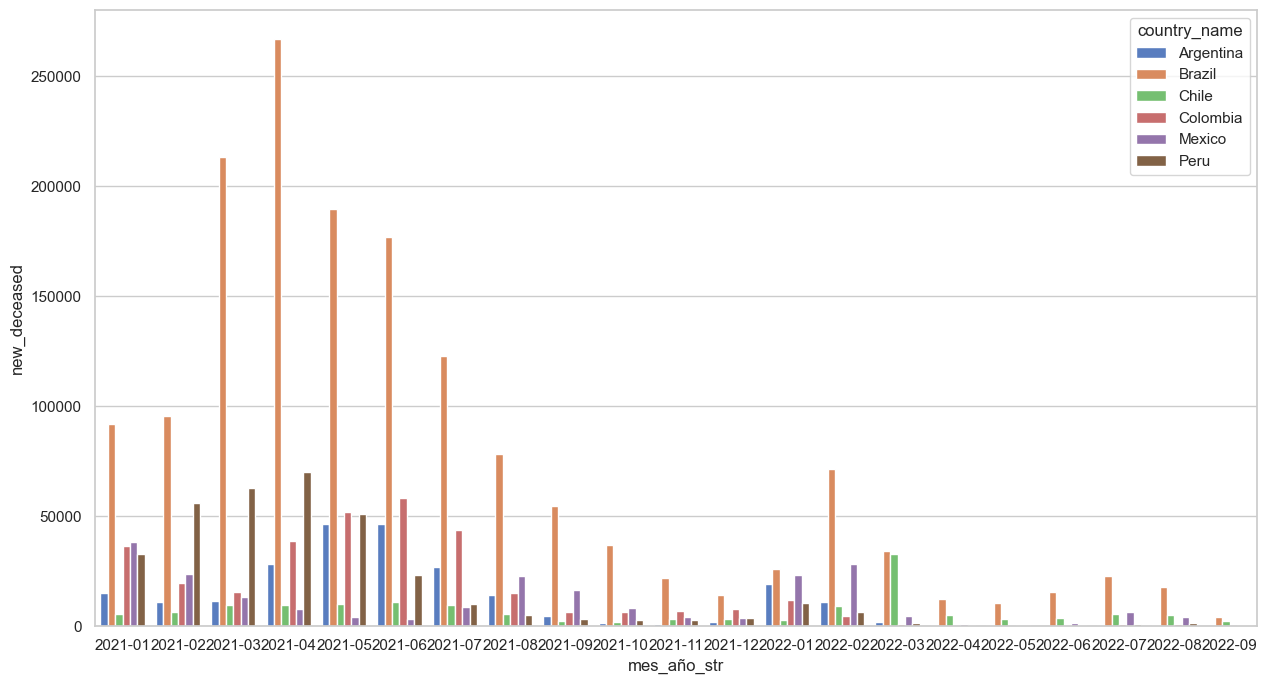

In [40]:
import matplotlib.ticker as ticker # Necesario para controlar el número de etiquetas

# 1. Asegurar que mes_año sea datetime para orden lógico
df_muertes_mes['mes_año'] = pd.to_datetime(df_muertes_mes['mes_año'])

# 2. Configuración del gráfico
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# 3. Crear el gráfico de barras
# Nota: Usamos una copia temporal de los datos formateados para el eje X
df_plot = df_muertes_mes.copy()
df_plot['mes_año_str'] = df_plot['mes_año'].dt.strftime('%Y-%m')

ax = sns.barplot(data=df_plot, x='mes_año_str', y='new_deceased', hue='country_name')

# --- MODIFICACIÓN PARA MOSTRAR SOLO 5 FECHAS ---
# Obtenemos todas las etiquetas actuales
all_labels = ax.get_xticklabels()
n = len(all_labels)


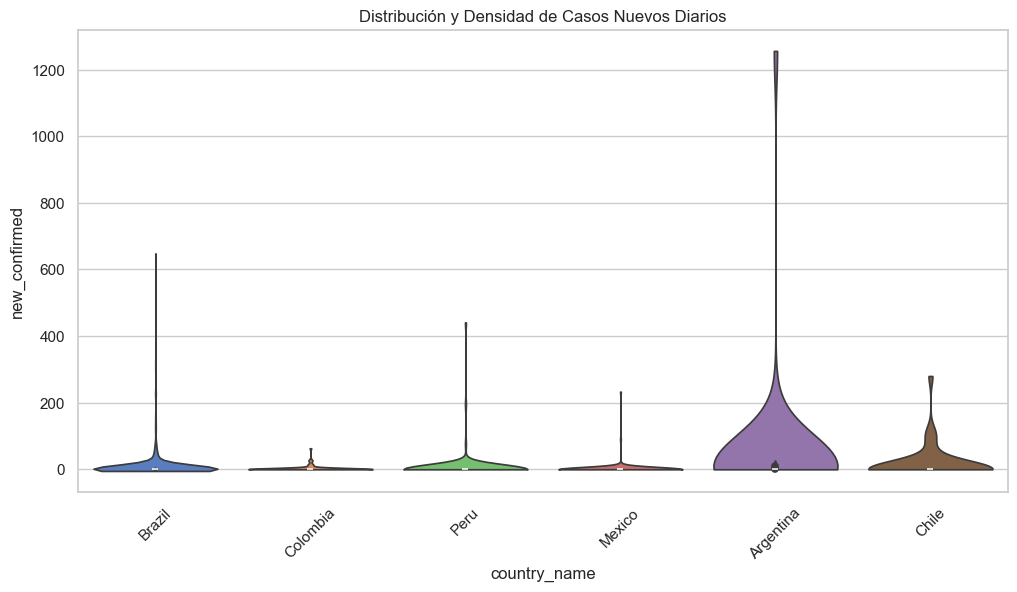

In [32]:
plt.clf()
plt.close('all')
plt.figure(figsize=(12, 6))

# Usamos una muestra para que sea instantáneo
sns.violinplot(data=datos_filtrados.sample(n=1000), x='country_name', y='new_confirmed', cut=0, palette="muted")
plt.title('Distribución y Densidad de Casos Nuevos Diarios')
plt.xticks(rotation=45)
plt.show()

#Avance numero 3 del proyecto integrador

In [ ]:
datos_filtrados.loc[:,'date'] = pd.to_datetime(datos_filtrados['date'])

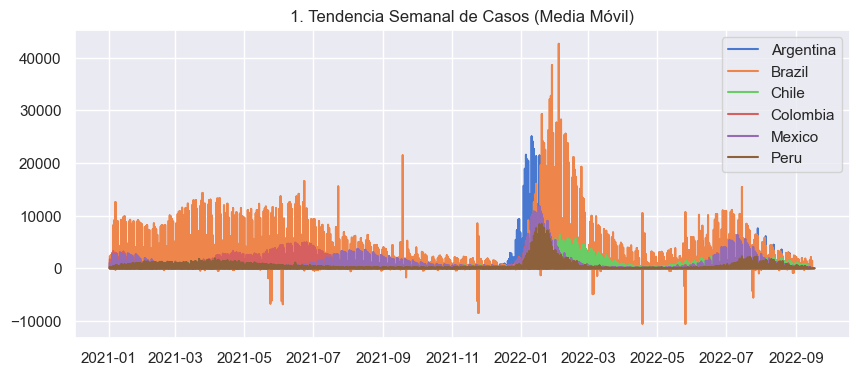

In [ ]:
# --- CASO 1: Evolución Semanal (Series Temporales con Suavizado) ---
plt.clf()
plt.close('all')
plt.figure(figsize=(10, 4))
for pais in datos_filtrados['country_name'].unique():
    # Usamos .copy() para evitar nuevos Warnings
    subset = datos_filtrados[datos_filtrados['country_name'] == pais].copy().set_index('date').sort_index()
    subset['suavizado'] = subset['new_confirmed'].rolling(window=7).mean()
    plt.plot(subset.index, subset['suavizado'], label=pais)
plt.title('1. Tendencia Semanal de Casos (Media Móvil)')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

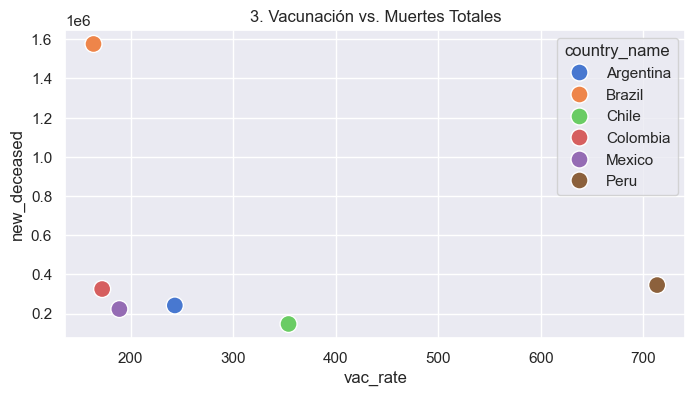

In [ ]:
# --- CASO 3: Cobertura de Vacunación vs Muertes (Efectividad) ---
plt.clf()
plt.close('all')
df_v = datos_filtrados.groupby('country_name').agg({'cumulative_vaccine_doses_administered':'max', 'new_deceased':'sum', 'population':'max'}).reset_index()
df_v['vac_rate'] = (df_v['cumulative_vaccine_doses_administered'] / df_v['population']) * 100
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_v, x='vac_rate', y='new_deceased', hue='country_name', s=150)
plt.title('3. Vacunación vs. Muertes Totales')
plt.show()

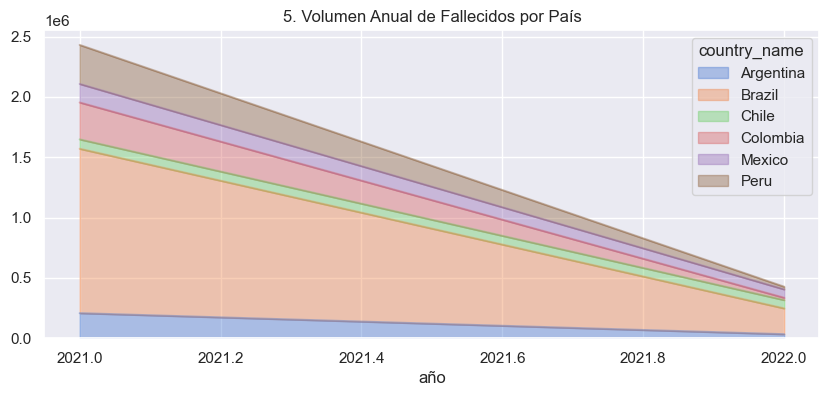

In [ ]:
# --- CASO 5: Evolución Anual de Mortalidad (Análisis Temporal) ---
plt.clf()
plt.close('all')
datos_filtrados.loc[:, 'año'] = datos_filtrados['date'].dt.year
df_a = datos_filtrados.groupby(['año', 'country_name'])['new_deceased'].sum().unstack().fillna(0)
df_a.plot(kind='area', alpha=0.4, figsize=(10, 4))
plt.title('5. Volumen Anual de Fallecidos por País')
plt.show()

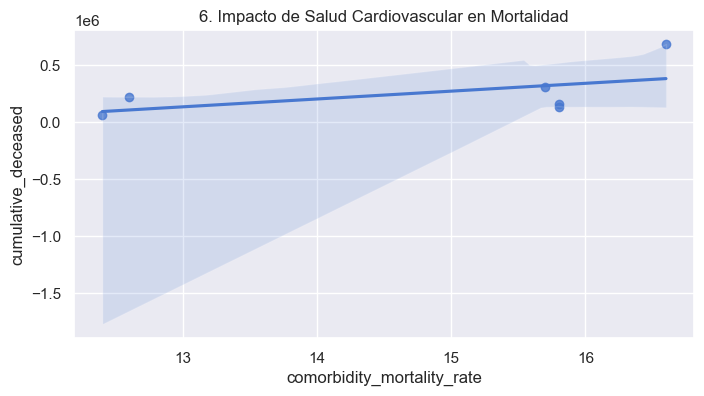

In [ ]:
# --- CASO 6: Prevalencia Cardiovascular vs Mortalidad ---
plt.clf()
plt.close('all')
plt.figure(figsize=(8, 4))
df_pre = datos_filtrados.groupby('country_name').agg({'comorbidity_mortality_rate':'max', 'cumulative_deceased':'max'}).reset_index()
sns.regplot(data=df_pre, x='comorbidity_mortality_rate', y='cumulative_deceased')
plt.title('6. Impacto de Salud Cardiovascular en Mortalidad')
plt.show()

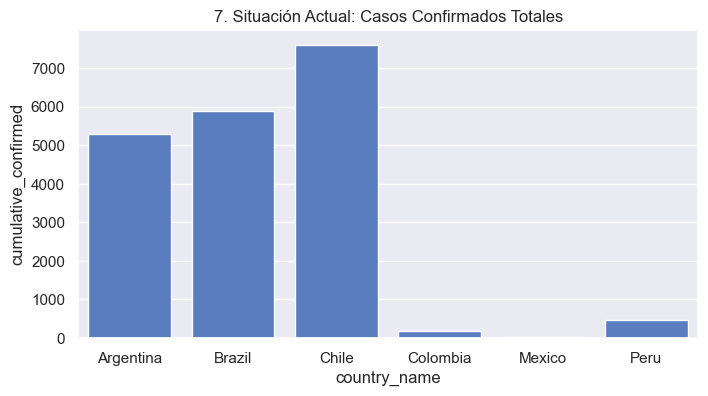

In [ ]:
# --- CASO 7: Situación Actual (Contexto Final de Datos) ---
plt.clf()
plt.close('all')
plt.figure(figsize=(8, 4))
df_l = datos_filtrados.sort_values('date').groupby('country_name').last().reset_index()
sns.barplot(data=df_l, x='country_name', y='cumulative_confirmed')
plt.title('7. Situación Actual: Casos Confirmados Totales')
plt.show()